In [96]:
from sentiment import helper, helper2


/Users/sjegoh/Documents/GitHub/NUSSIF/regional_project/venv-regional/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 41605.64it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [97]:
# In a Jupyter Notebook cell:
try:
    # We call 'await' directly because Notebooks support top-level await
    df_clean, fx_data, bond_data = await helper()
    
    # helper2 is a standard function, so no await needed here
except Exception as e:
    print(f"Error during execution: {e}")


🚀 Accessing BNM...
--- Scraping Page 1 ---
📄 [1] Processing: Governor's Keynote Address at the Central Banking ...
📄 [2] Processing: Deputy Governor's Opening Remarks at the Financing...
📄 [3] Processing: Deputy Governor's Closing Remarks at the SEACEN Po...
📄 [4] Processing: Governor's Opening Remarks at the SEACEN Policy Su...
📄 [5] Processing: Deputy Governor's Keynote Speech at the Launch of ...
📄 [6] Processing: Assistant Governor's Speech at the PPKM Annual Din...
📄 [7] Processing: Ucapan Gabenor di Peringkat Akhir Pertandingan Pid...
📄 [8] Processing: Governor's Keynote Address at the Malaysian e-Paym...
📄 [9] Processing: Assistant Governor's Keynote Presentation at the K...
📄 [10] Processing: Assistant Governor's Keynote Address at the JC3 SM...
📄 [11] Processing: Governor's Keynote Address at the 48th Federation ...
📄 [12] Processing: Deputy Governor's Speech at the Closing of Karniva...
📄 [13] Processing: Governor's Welcoming Speech at the Launch of Karni...
📄 [14] Processing

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [98]:
import torch
import pandas as pd
import re
import asyncio
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from deep_translator import GoogleTranslator
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.dates as mdates
from scipy import stats
import numpy as np


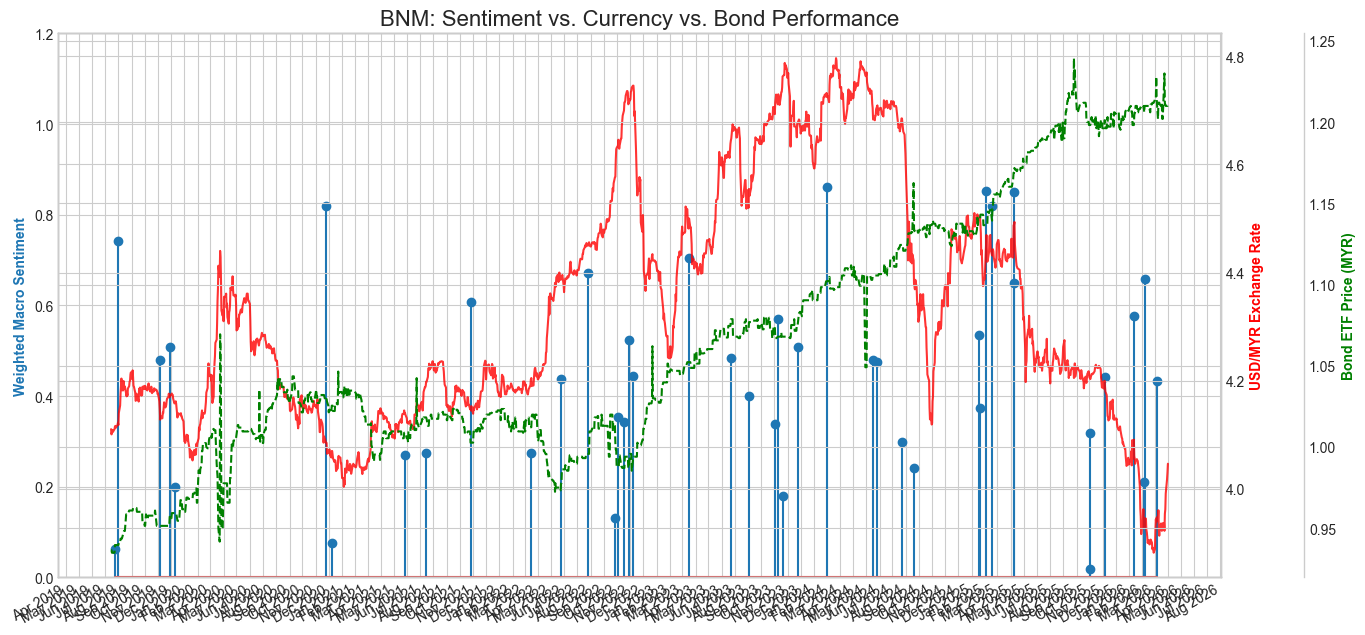


--- Multi-Horizon Robust Analysis ---
    Horizon     Asset    Corr  p-value
0    3 Days   USD/MYR -0.2695   0.0769
1   30 Days   USD/MYR -0.1305   0.3984
2  100 Days   USD/MYR -0.0822   0.5958
0    3 Days  Bond ETF  0.3169   0.0361
1   30 Days  Bond ETF  0.2701   0.0763
2  100 Days  Bond ETF  0.2113   0.1686


In [99]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
fx_data['Date'] = pd.to_datetime(fx_data['Date']).dt.tz_localize(None)
bond_data['Date'] = pd.to_datetime(bond_data['Date']).dt.tz_localize(None)

# Plotting code remains the same as your request
fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.stem(df_clean['Date'], df_clean['Sentiment'], linefmt='C0-', markerfmt='C0o', label='BNM Sentiment')
ax1.set_ylabel('Weighted Macro Sentiment', color='C0', fontweight='bold')
ax1.set_ylim(0, 1.2)

ax2 = ax1.twinx()
ax2.plot(fx_data['Date'].values, fx_data['Close'].values, color='red', linewidth=1.5, label='USD/MYR Spot', alpha=0.8)
ax2.set_ylabel('USD/MYR Exchange Rate', color='red', fontweight='bold')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(bond_data['Date'].values, bond_data['Close'].values, color='green', linewidth=1.5, label='ABF Bond ETF (0800EA.KL)', linestyle='--')
ax3.set_ylabel('Bond ETF Price (MYR)', color='green', fontweight='bold')

ax1.xaxis_date() 
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate()
plt.title('BNM: Sentiment vs. Currency vs. Bond Performance', fontsize=16)
plt.show()

# Robust Horizon Evaluation
def evaluate_horizons_robust(df_sent, mkt_data, horizons=[3, 30, 100], label="FX"):
    # 1. Normalize resolution to nanoseconds (ns) and strip timezones
    # We call .astype() on the Series, NOT the .dt accessor
    df_sent['Date'] = pd.to_datetime(df_sent['Date']).astype('datetime64[ns]')
    
    # For market data, we strip the timezone first, THEN cast
    mkt_data['Date'] = pd.to_datetime(mkt_data['Date']).dt.tz_localize(None).astype('datetime64[ns]')
    
    # 2. Sort is MANDATORY for merge_asof
    df_sent = df_sent.sort_values('Date')
    mkt_data = mkt_data.sort_values('Date')
    
    results = []
    # ... rest of your loop logic
    # ... rest of your loop logic
    for h in horizons:
        mkt_temp = mkt_data.copy()
        mkt_temp['Target_Date'] = mkt_temp['Date'] + pd.Timedelta(days=h)
        mkt_future = pd.merge_asof(mkt_temp[['Target_Date']], mkt_data[['Date', 'Close']], left_on='Target_Date', right_on='Date', direction='backward').rename(columns={'Close': 'Future_Price'})
        mkt_temp['Forward_Return'] = (mkt_future['Future_Price'] - mkt_temp['Close']) / mkt_temp['Close']
        merged = pd.merge_asof(df_sent, mkt_temp[['Date', 'Forward_Return']], on='Date', direction='backward')
        valid = merged.dropna(subset=['Forward_Return'])
        if len(valid) > 2:
            r, p = stats.pearsonr(valid['Sentiment'], valid['Forward_Return'])
            results.append({'Horizon': f'{h} Days', 'Asset': label, 'Corr': round(r, 4), 'p-value': round(p, 4)})
    return pd.DataFrame(results)

print("\n--- Multi-Horizon Robust Analysis ---")
fx_results = evaluate_horizons_robust(df_clean, fx_data, label="USD/MYR")
bond_results = evaluate_horizons_robust(df_clean, bond_data, label="Bond ETF")
print(pd.concat([fx_results, bond_results]))




In [100]:
def evaluate_horizons_robust_diffs(df_sent, mkt_data, horizons=[3, 30, 100], label="FX"):
    # 1. Pre-process dates and sort (Crucial for merge_asof and diff calculations)
    df_sent = df_sent.copy()
    mkt_data = mkt_data.copy()
    
    df_sent['Date'] = pd.to_datetime(df_sent['Date']).dt.tz_localize(None).astype('datetime64[ns]')
    mkt_data['Date'] = pd.to_datetime(mkt_data['Date']).dt.tz_localize(None).astype('datetime64[ns]')
    
    df_sent = df_sent.sort_values('Date')
    mkt_data = mkt_data.sort_values('Date')

    # 2. CALCULATE DIFFERENCES (The Change in Sentiment)
    # This captures the 'Surprise' factor (Sentiment at t minus Sentiment at t-1)
    df_sent['Sentiment_Diff'] = df_sent['Sentiment'].diff()

    results = []

    for h in horizons:
        mkt_temp = mkt_data.copy()
        
        # 3. CALCULATE FORWARD LOG RETURNS (Standard for price differences)
        # Using Log Returns ensures the differences are additive and normalized
        mkt_temp['Log_Price'] = np.log(mkt_temp['Close'])
        
        # Shift prices back by 'h' periods to get the future price
        # Note: In a daily index, 'h' periods approx 'h' days. 
        # For precise calendar days, use the Target_Date merge logic below:
        
        mkt_temp['Target_Date'] = mkt_temp['Date'] + pd.Timedelta(days=h)
        
        mkt_future = pd.merge_asof(
            mkt_temp[['Target_Date']], 
            mkt_temp[['Date', 'Log_Price']], 
            left_on='Target_Date', 
            right_on='Date', 
            direction='backward'
        ).rename(columns={'Log_Price': 'Future_Log_Price'})
        
        # Difference in Log Prices = Log Return
        mkt_temp['Forward_Diff_Return'] = mkt_future['Future_Log_Price'].values - mkt_temp['Log_Price'].values
        
        # 4. Merge Sentiment Change with Forward Price Change
        merged = pd.merge_asof(df_sent, mkt_temp[['Date', 'Forward_Diff_Return']], on='Date', direction='backward')
        
        # Drop the first row of Sentiment_Diff (it's NaN) and any missing returns
        valid = merged.dropna(subset=['Sentiment_Diff', 'Forward_Diff_Return'])
        
        if len(valid) > 2:
            # Correlation between CHANGE in sentiment and CHANGE in future price
            r, p = stats.pearsonr(valid['Sentiment_Diff'], valid['Forward_Diff_Return'])
            results.append({
                'Horizon': f'{h} Days', 
                'Asset': label, 
                'Corr (Δ)': round(r, 4), 
                'p-value': round(p, 4),
                'N': len(valid)
            })
            
    return pd.DataFrame(results)

print("\n--- Multi-Horizon Difference-Based Analysis ---")
fx_diff_results = evaluate_horizons_robust_diffs(df_clean, fx_data, label="USD/MYR")
bond_diff_results = evaluate_horizons_robust_diffs(df_clean, bond_data, label="Bond ETF")
print(pd.concat([fx_diff_results, bond_diff_results]))



--- Multi-Horizon Difference-Based Analysis ---
    Horizon     Asset  Corr (Δ)  p-value   N
0    3 Days   USD/MYR   -0.1223   0.4346  43
1   30 Days   USD/MYR    0.0130   0.9339  43
2  100 Days   USD/MYR   -0.0001   0.9996  43
0    3 Days  Bond ETF    0.2397   0.1216  43
1   30 Days  Bond ETF    0.3293   0.0310  43
2  100 Days  Bond ETF    0.1667   0.2855  43


In [101]:
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.preprocessing import StandardScaler

def run_granger_test_standardized(df_clean, mkt_data, max_lag=15):
    # 1. Calculate Sentiment CHANGE on the specific speech dates ONLY
    df_clean = df_clean.sort_values('Date').copy()
    df_clean['Sent_Diff'] = df_clean['Sentiment']
    
    # 2. Prepare Market Data
    mkt_data = mkt_data.sort_values('Date').copy()
    mkt_data['Mkt_Ret'] = mkt_data['Close'].pct_change()
    
    # 3. Merge Sentiment DIFF onto the daily Market Timeline
    test_df = pd.merge(mkt_data[['Date', 'Mkt_Ret']], 
                       df_clean[['Date', 'Sent_Diff']], 
                       on='Date', how='left').fillna(0)
    
    # 4. THE STANDARDIZATION STEP
    # We transform both variables into Z-Scores
    scaler = StandardScaler()
    test_df[['Mkt_Ret_Z', 'Sent_Diff_Z']] = scaler.fit_transform(test_df[['Mkt_Ret', 'Sent_Diff']])
    
    # Drop first row (NaN)
    final_data = test_df[['Mkt_Ret_Z', 'Sent_Diff_Z']].dropna()
    
    print(f"\n--- Standardized Granger Causality Test (Z-Scores) ---")
    # [Dependent (Y), Independent (X)]
    results = grangercausalitytests(final_data[['Mkt_Ret_Z', 'Sent_Diff_Z']], maxlag=max_lag, verbose=True)
    
    return results

# Run the standardized test for Bond Data
standard_granger = run_granger_test_standardized(df_clean, fx_data)



--- Standardized Granger Causality Test (Z-Scores) ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.0886  , p=0.1486  , df_denom=1743, df_num=1
ssr based chi2 test:   chi2=2.0921  , p=0.1481  , df=1
likelihood ratio test: chi2=2.0909  , p=0.1482  , df=1
parameter F test:         F=2.0886  , p=0.1486  , df_denom=1743, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.7614  , p=0.1721  , df_denom=1740, df_num=2
ssr based chi2 test:   chi2=3.5329  , p=0.1709  , df=2
likelihood ratio test: chi2=3.5293  , p=0.1712  , df=2
parameter F test:         F=1.7614  , p=0.1721  , df_denom=1740, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.6815  , p=0.0117  , df_denom=1737, df_num=3
ssr based chi2 test:   chi2=11.0889 , p=0.0113  , df=3
likelihood ratio test: chi2=11.0538 , p=0.0114  , df=3
parameter F test:         F=3.6815  , p=0.0117  , df_denom=1737, df_num=3

Granger Causality
number of lag

/Users/sjegoh/Documents/GitHub/NUSSIF/regional_project/venv-regional/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [102]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_rolling_regime_analysis(df_sent, df_bond, window=252):
    # 1. Sync and Calculate (MA30 and Forward 30D Ret)
    df_sent = df_sent.sort_values('Date').copy()
    df_bond = df_bond.sort_values('Date').copy()
    
    df_sent['Sent_MA30'] = df_sent['Sentiment'].rolling(window=30).mean()
    df_bond['Forward_30D_Ret'] = df_bond['Close'].pct_change(30).shift(-30)
    
    # 2. Merge on Date
    combined = pd.merge(df_bond[['Date', 'Forward_30D_Ret']], 
                        df_sent[['Date', 'Sent_MA30']], 
                        on='Date', how='inner').dropna()
    
    # 3. Calculate Rolling Correlation (1-Year Window)
    combined['Rolling_Corr'] = combined['Forward_30D_Ret'].rolling(window=window).corr(combined['Sent_MA30'])
    
    # 4. Plotting
    plt.figure(figsize=(14, 7))
    plt.plot(combined['Date'], combined['Rolling_Corr'], color='#2c3e50', linewidth=2, label='1-Year Rolling Correlation')
    
    # Add a horizontal line for your -0.61 average
    plt.axhline(y=-0.61, color='red', linestyle='--', alpha=0.6, label='Overall Average (-0.61)')
    plt.axhline(y=0, color='black', alpha=0.2)
    
    plt.fill_between(combined['Date'], combined['Rolling_Corr'], -0.61, where=(combined['Rolling_Corr'] < -0.61), color='green', alpha=0.1, label='Stronger than Avg')
    plt.fill_between(combined['Date'], combined['Rolling_Corr'], -0.61, where=(combined['Rolling_Corr'] > -0.61), color='orange', alpha=0.1, label='Weaker than Avg')

    plt.title('Time-Varying Regime Correlation: BNM Sentiment vs. Bond Returns', fontsize=14)
    plt.ylabel('Correlation Coefficient (r)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 5. Annual Breakdown for your report
    combined['Year'] = combined['Date'].dt.year
    annual_corr = combined.groupby('Year').apply(lambda x: x['Forward_30D_Ret'].corr(x['Sent_MA30']))
    print("\n--- Annual Regime Correlation ---")
    print(annual_corr)
    print(f"Sentiment Data starts: {df_clean['Date'].min()}")
    print(f"Bond Data starts:      {bond_data['Date'].min()}")
    print(f"Merged Data starts:    {combined['Date'].min()}")

# Run the analysis
def recover_history_analysis(df_sent, df_bond):
    # 1. Start with the Bond Data (continuous timeline)
    full_df = df_bond[['Date', 'Close']].sort_values('Date').copy()
    full_df['Forward_30D_Ret'] = full_df['Close'].pct_change(30).shift(-30)
    
    # 2. Left Join Sentiment (Keep all Bond dates)
    combined = pd.merge(full_df, df_sent[['Date', 'Sentiment']], on='Date', how='left')
    
    # 3. CRITICAL STEP: Forward Fill the policy stance
    # This assumes BNM's stance stays the same until the next speech
    combined['Sentiment'] = combined['Sentiment'].ffill()
    
    # 4. Now calculate the MA on the filled data
    combined['Sent_MA30'] = combined['Sentiment'].rolling(window=30).mean()
    
    # 5. Drop only the very beginning/end where windows can't be full
    final = combined.dropna(subset=['Sent_MA30', 'Forward_30D_Ret'])
    
    print(f"NEW Merged Data starts: {final['Date'].min()}")
    return final

# Run this and re-check annual correlations
df_recovered = recover_history_analysis(df_clean, fx_data)
annual_corr_recovered = df_recovered.groupby(df_recovered['Date'].dt.year).apply(
    lambda x: x['Forward_30D_Ret'].corr(x['Sent_MA30'])
)
print(annual_corr_recovered)


NEW Merged Data starts: 2019-09-03 00:00:00
Date
2019    0.377769
2020    0.030153
2021   -0.354570
2022    0.382497
2023    0.280692
2024   -0.134988
2025    0.024256
2026    0.971872
dtype: float64


In [103]:
def check_trigger_efficiency(df_recovered):
    # 1. Calculate Z-Scores for Sentiment
    # This tells us how 'Extreme' a speech is relative to the 7-year history
    mu = df_recovered['Sent_MA30'].mean()
    sigma = df_recovered['Sent_MA30'].std()
    df_recovered['Sent_Z'] = (df_recovered['Sent_MA30'] - mu) / sigma

    # 2. Define our "Trigger" thresholds (Standard Deviations)
    thresholds = [0.5, 1.0, 1.5, 2.0]
    
    print(f"{'Threshold (Z)':<15} | {'N Days':<8} | {'Correlation (r)':<15}")
    print("-" * 45)
    
    for t in thresholds:
        # Filter for days where sentiment is more extreme than 't'
        subset = df_recovered[df_recovered['Sent_Z'].abs() > t]
        
        if len(subset) > 1:
            corr = subset['Sent_MA30'].corr(subset['Forward_30D_Ret'])
            print(f"|Z| > {t:<10.1f} | {len(subset):<8} | {corr:<15.4f}")
        else:
            print(f"|Z| > {t:<10.1f} | {len(subset):<8} | Insufficient Data")

# Run the Trigger Test
check_trigger_efficiency(df_recovered)


Threshold (Z)   | N Days   | Correlation (r)
---------------------------------------------
|Z| > 0.5        | 1216     | -0.0760        
|Z| > 1.0        | 737      | -0.0978        
|Z| > 1.5        | 238      | -0.5239        
|Z| > 2.0        | 50       | -0.1669        


In [104]:
import numpy as np
import pandas as pd

class RegimeTactician:
    def __init__(self, lookback_days=60):
        self.lookback = lookback_days
        self.threshold = 1.5  # Your "Golden Z-Score"
        
    def get_market_state(self, df_combined):
        """
        Analyzes the last 60 days to see if the 'Signal' is currently working.
        Returns: 'Active', 'Flipped', or 'Noise'
        """
        recent_data = df_combined.tail(self.lookback)
        recent_corr = recent_data['Sent_MA30'].corr(recent_data['Forward_30D_Ret'])
        
        if recent_corr < -0.4:
            return "Active (Hawkish = MYR Strength)"
        elif recent_corr > 0.4:
            return "Flipped (Hawkish = MYR Weakness)"
        else:
            return "Noise (No Alpha)"

    def sniper_trigger(self, current_sentiment_z, state):
        """
        The final Execution Gate.
        """
        # Logic: Only trade if we have Conviction AND a clear Regime
        if abs(current_sentiment_z) < self.threshold:
            return "HOLD: Low Conviction (|Z| < 1.5)"
        
        if "Noise" in state:
            return "HOLD: Regime is currently Noise"
            
        if "Active" in state:
            if current_sentiment_z > self.threshold:
                return "EXECUTE: LONG MYR (Strong Signal)"
            else:
                return "EXECUTE: SHORT MYR (Strong Signal)"
                
        if "Flipped" in state:
            # In 2026, Hawkish (+Z) might mean a weaker Ringgit
            if current_sentiment_z > self.threshold:
                return "EXECUTE: SHORT MYR (Contrarian/Flipped Signal)"
            
        return "WAIT"

# Usage in your main AI loop:
tactician = RegimeTactician()
current_state = tactician.get_market_state(df_recovered)
print(current_state)


Noise (No Alpha)


Changes in sentiment generally reflected in 3 days in exchange rate. Seems tradable...?

[*********************100%***********************]  1 of 1 completed


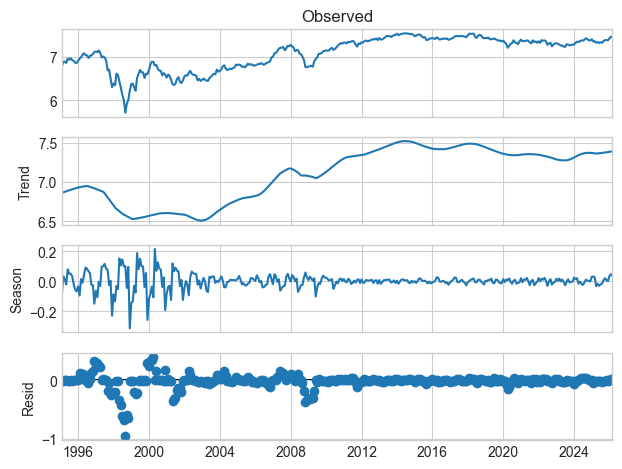

In [105]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 1. Get Data
ticker = "^KLSE"
data = yf.download(ticker, start="1995-01-01", end="2026-03-01")
prices = data['Close'].resample('ME').last().ffill() # Monthly resample

# 2. Log transform to handle exponential growth/percentage changes
log_prices = np.log(prices)

# 3. Apply STL
# period=12 because we are looking for annual (monthly) seasonality
stl = STL(log_prices, period=12, robust=True)
res = stl.fit()

# 4. Plot the components
fig = res.plot()
plt.show()


In [106]:
# Extract the seasonal component
seasonal_component = res.seasonal

# Group by month to see the average 'strength' of the season
monthly_seasonality = seasonal_component.groupby(seasonal_component.index.month).mean()

# Convert back from log scale to see approximate % impact
impact_pct = (np.exp(monthly_seasonality) - 1) * 100
# 1. Calculate Monthly Returns from your original 'prices' series
monthly_returns = prices.pct_change()

# 2. Define a 'Win' (True if return > 0)
is_win = monthly_returns > 0

# 3. Group by month to get the Win Rate (%)
# we multiply by 100 to get a percentage
win_rate = is_win.groupby(is_win.index.month).mean() * 100

# 4. Combine with your existing 'impact_pct' (Seasonality Strength)
# 1. Flatten the seasonal strength and win rate to ensure they are 1D
# .squeeze() turns a (12, 1) into a (12,)
strength_1d = impact_pct.squeeze()
win_rate_1d = win_rate.squeeze()

# 2. Combine into DataFrame
seasonality_analysis = pd.DataFrame({
    'Seasonal Strength (%)': strength_1d,
    'Win Rate (%)': win_rate_1d
})

# 3. Format
seasonality_analysis.index.name = 'Month'
print(seasonality_analysis.round(2))


       Seasonal Strength (%)  Win Rate (%)
Month                                     
1                      -1.25         53.12
2                       0.48         62.50
3                      -1.63         45.16
4                       3.03         58.06
5                       0.77         45.16
6                       1.35         51.61
7                       1.77         51.61
8                       1.64         41.94
9                      -0.70         38.71
10                      0.94         67.74
11                     -4.60         38.71
12                     -1.20         90.32


--- KELLY-SIZED SEASONAL RISK REPORT ---
Total Return:      111.88%
Annualized Sharpe: 0.5449
Max Drawdown:      -16.30%
--- SIZING ANALYSIS ---
Max Position Size: 82.3%
Min Position Size: 3.7% (Active Trades Only)


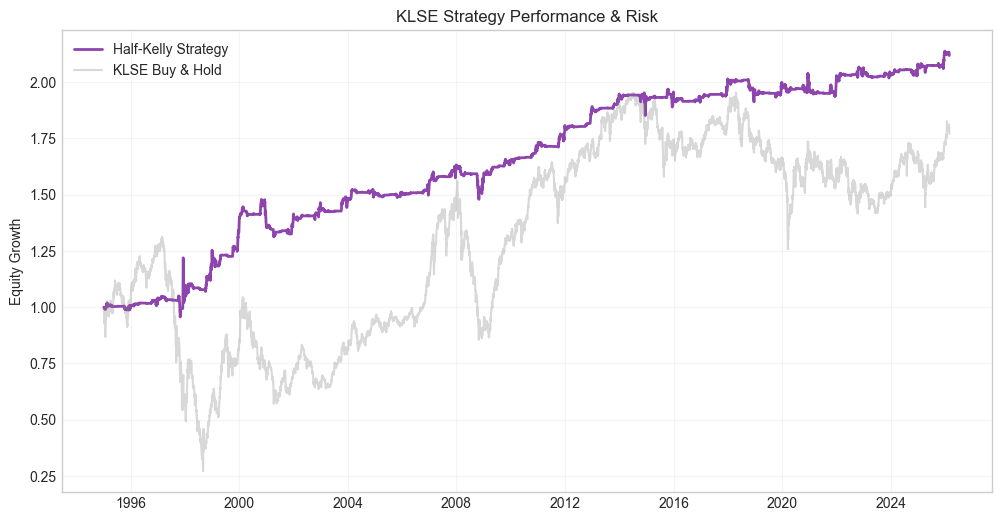

In [107]:
def run_seasonal_backtest_kelly(data, seasonality_analysis):
    df = data.copy()
    
    # 1. Prepare seasonality and monthly stats for Win/Loss Ratio (R)
    seasonality_analysis.index = seasonality_analysis.index.astype(int)
    df['Month'] = df.index.month
    df['Market_Ret'] = df['Close'].pct_change()
    
    # Calculate historical Win/Loss Ratio per month to get 'R'
    monthly_stats = {}
    for m in range(1, 13):
        m_rets = df[df['Month'] == m]['Market_Ret'].dropna()
        pos_rets = m_rets[m_rets > 0].mean()
        neg_rets = abs(m_rets[m_rets < 0].mean())
        monthly_stats[m] = pos_rets / neg_rets if neg_rets != 0 else 1.0

    # 2. Map Kelly Components
    df['W'] = df['Month'].map(seasonality_analysis['Win Rate (%)']) / 100.0
    df['R'] = df['Month'].map(monthly_stats)
    
    # Kelly Formula: K = W - ((1-W)/R)
    df['Kelly_Fraction'] = df['W'] - ((1 - df['W']) / df['R'])
    df['Sizing_Factor'] = df['Kelly_Fraction'] * 1.0 # Half-Kelly
    
    # 3. Execution Logic
    kelly_arr = df['Sizing_Factor'].values.flatten()
    win_rate_arr = df['W'].values.flatten()

    # Rule: Only trade if Kelly is positive (>0) and Win Rate > 50%
    df['Position_Size'] = np.where(
        (kelly_arr > 0) & (win_rate_arr > 0.5),
        kelly_arr.clip(0, 1.0), 
        0
    )

    # 4. Calculate Strategy Returns
    df['Strategy_Ret'] = df['Position_Size'].shift(1) * df['Market_Ret']
    
    # 5. Metrics & Performance
    clean_rets = df['Strategy_Ret'].dropna()
    cumulative_ret = (1 + clean_rets).cumprod()
    
    if not cumulative_ret.empty:
        # --- NEW METRICS CALCULATIONS ---
        total_ret = (cumulative_ret.iloc[-1] - 1) * 100
        vol = clean_rets.std() * np.sqrt(252)
        sharpe = (clean_rets.mean() * 252) / vol if vol != 0 else 0
        
        # Max Drawdown: Peak to Trough
        rolling_max = cumulative_ret.cummax()
        drawdowns = (cumulative_ret - rolling_max) / rolling_max
        max_dd = drawdowns.min() * 100
        
        # Sizing Extremes (Active trades only for Min)
        max_size = df['Position_Size'].max()
        active_sizes = df[df['Position_Size'] > 0]['Position_Size']
        min_size = active_sizes.min() if not active_sizes.empty else 0

        print(f"--- KELLY-SIZED SEASONAL RISK REPORT ---")
        print(f"Total Return:      {total_ret:.2f}%")
        print(f"Annualized Sharpe: {sharpe:.4f}")
        print(f"Max Drawdown:      {max_dd:.2f}%")
        print(f"--- SIZING ANALYSIS ---")
        print(f"Max Position Size: {max_size*100:.1f}%")
        print(f"Min Position Size: {min_size*100:.1f}% (Active Trades Only)")
        
        # Plotting remains the same
        plt.figure(figsize=(12, 6))
        plt.plot(cumulative_ret, label="Half-Kelly Strategy", color='#8e44ad', linewidth=2)
        plt.plot((1 + df['Market_Ret'].dropna()).cumprod(), label="KLSE Buy & Hold", alpha=0.3, color='gray')
        plt.title("KLSE Strategy Performance & Risk")
        plt.ylabel("Equity Growth")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()
    else:
        print("Error: No trade data generated.")

# Run it
run_seasonal_backtest_kelly(data, seasonality_analysis)


EWMA Strategy (Span=10Y): 2005 - 2026
--- EWMA CONVICTION (SPAN 10Y) ---
Total Return:      105.35%
Annualized Sharpe: 0.6792
Max Drawdown:      -26.07%


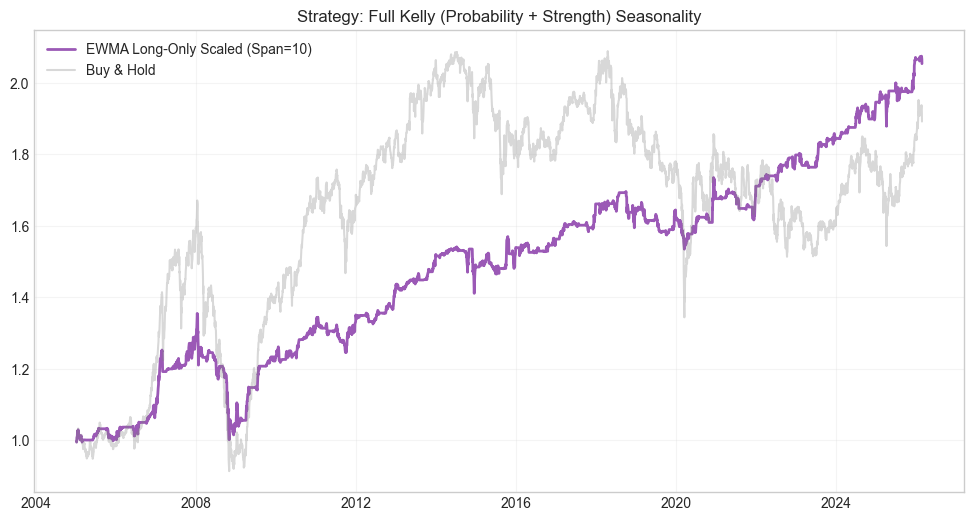

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_ewma_conviction_long_only(data, span=30, scale_conviction=True):
    df = data.copy()
    
    # Handle MultiIndex columns if they exist
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    df['Market_Ret'] = df['Close'].pct_change()
    df['Month'] = df.index.month
    df['Strategy_Ret'] = 0.0
    
    DATA_START_YEAR = df.index.year.min()
    TRADING_START_YEAR = DATA_START_YEAR + span
    END_YEAR = df.index.year.max()
    
    print(f"EWMA Strategy (Span={span}Y): {TRADING_START_YEAR} - {END_YEAR}")

    for year in range(TRADING_START_YEAR, END_YEAR + 1):
        # 1. TRAIN: All data before the current year
        train_data = df[df.index.year < year].copy()
        
        # 2. Calculate EWMA for Probability AND Strength
        train_data['is_win'] = (train_data['Market_Ret'] > 0).astype(int)
        
        # Separate the actual return magnitudes
        train_data['win_ret'] = np.where(train_data['Market_Ret'] > 0, train_data['Market_Ret'], np.nan)
        train_data['loss_ret'] = np.where(train_data['Market_Ret'] < 0, np.abs(train_data['Market_Ret']), np.nan)
        
        # Group by year and month to get the averages for each specific month
        yearly_stats = train_data.groupby([train_data.index.year, 'Month']).agg(
            win_rate=('is_win', 'mean'),
            avg_win=('win_ret', 'mean'),
            avg_loss=('loss_ret', 'mean')
        ).unstack('Month')
        
        # Apply EWMA to all three metrics
        ewma_win_rate = yearly_stats['win_rate'].ewm(span=span).mean().iloc[-1]
        ewma_avg_win = yearly_stats['avg_win'].ewm(span=span).mean().iloc[-1]
        ewma_avg_loss = yearly_stats['avg_loss'].ewm(span=span).mean().iloc[-1]

        # 3. TEST: Apply to the current year
        current_year_mask = df.index.year == year
        
        # --- PRE-CALCULATE RELATIVE CONVICTION (FULL KELLY) ---
        raw_sizes = {}
        for month in range(1, 13):
            p = ewma_win_rate[month]
            avg_w = ewma_avg_win[month]
            avg_l = ewma_avg_loss[month]
            
            # Handle edge cases (e.g., a historically perfect month with zero losses)
            if pd.isna(avg_l) or avg_l == 0:
                k_size = p 
            elif pd.isna(avg_w) or p == 0:
                k_size = 0
            else:
                # Full Kelly Formula
                payoff_ratio = avg_w / avg_l
                k_size = p - ((1 - p) / payoff_ratio)
            
            # Bound at 0 (No shorting)
            raw_sizes[month] = k_size if k_size > 0 else 0
            
        # Find the month with the strongest historical edge for this year
        max_conviction = max(raw_sizes.values()) if raw_sizes.values() else 0
        
        for month in range(1, 13):
            if scale_conviction and max_conviction > 0:
                # Normalize so the highest conviction month is exactly 1.0 (100%)
                size = raw_sizes[month] / max_conviction
            else:
                # Fallback to standard full Kelly bounded at 1.0
                size = min(raw_sizes[month], 1.0)
                
            month_mask = (df['Month'] == month) & current_year_mask
            df.loc[month_mask, 'Strategy_Ret'] = size * df.loc[month_mask, 'Market_Ret']

    # 4. METRICS
    trading_df = df[df.index.year >= TRADING_START_YEAR].copy()
    clean_rets = trading_df['Strategy_Ret'].dropna()
    cumulative_ret = (1 + clean_rets).cumprod()
    
    if not cumulative_ret.empty:
        total_ret = (cumulative_ret.iloc[-1] - 1) * 100
        sharpe = (clean_rets.mean() * 252) / (clean_rets.std() * np.sqrt(252))
        max_dd = ((cumulative_ret - cumulative_ret.cummax()) / cumulative_ret.cummax()).min() * 100

        print(f"--- EWMA CONVICTION (SPAN {span}Y) ---")
        print(f"Total Return:      {total_ret:.2f}%")
        print(f"Annualized Sharpe: {sharpe:.4f}")
        print(f"Max Drawdown:      {max_dd:.2f}%")
        
        plt.figure(figsize=(12, 6))
        plt.plot(cumulative_ret, label=f"EWMA Long-Only Scaled (Span={span})", color='#9b59b6', lw=2)
        plt.plot((1 + trading_df['Market_Ret']).cumprod(), label="Buy & Hold", alpha=0.3, color='gray')
        plt.title(f"Strategy: Full Kelly (Probability + Strength) Seasonality")
        plt.legend(); plt.grid(True, alpha=0.2); plt.show()
        
    return trading_df, cumulative_ret

# Execute
ewma_df, ewma_cum = run_ewma_conviction_long_only(data, span=10, scale_conviction=True)


🚀 Initializing Strategy | Filter: None | Span: 10Y
---------------------------------------------
      STRATEGY EDGE PROFILE (2005-2026)
---------------------------------------------
Total Return:      67.75%
Annualized Sharpe: 0.5017
Max Drawdown:      -26.27%
Slippage Drag:     -17.30% (at 15 bps)
---------------------------------------------
Win Rate:          52.21%
Avg Daily Profit:  0.2565%
Avg Daily Loss:    -0.2437%
Profit/Loss Ratio: 1.05
Total Trade Count: 239
---------------------------------------------


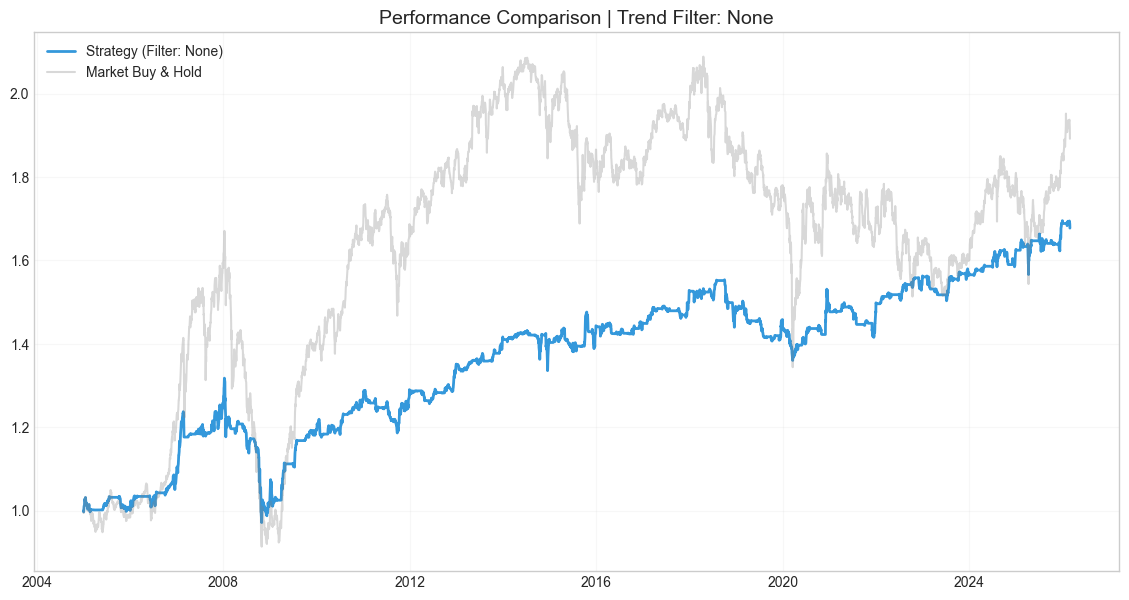

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_ewma_conviction_with_exit(data, span=10, scale_conviction=True, slippage_bps=25, trend_filter=100):
    df = data.copy()
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    df['Market_Ret'] = df['Close'].pct_change()
    df['Month'] = df.index.month
    
    # --- 1. TREND FILTER OPTION ---
    if trend_filter is not None and trend_filter > 0:
        df['MA'] = df['Close'].rolling(window=trend_filter).mean()
        df['Trend_Signal'] = np.where(df['Close'] > df['MA'], 1.0, 0.0)
        df['Trend_Signal'] = df['Trend_Signal'].shift(1) # CRITICAL FIX
        filter_label = f"{trend_filter}D MA"
    else:
        # No Trend Filter: Always 1.0
        df['Trend_Signal'] = 1.0
        filter_label = "None"
    
    df['Target_Weight'] = 0.0 
    
    DATA_START_YEAR = df.index.year.min()
    TRADING_START_YEAR = DATA_START_YEAR + span 
    END_YEAR = df.index.year.max()
    
    print(f"🚀 Initializing Strategy | Filter: {filter_label} | Span: {span}Y")

    for year in range(TRADING_START_YEAR, END_YEAR + 1):
        # --- TRAIN ---
        train_data = df[df.index.year < year].copy()
        train_data['is_win'] = (train_data['Market_Ret'] > 0).astype(int)
        train_data['win_ret'] = np.where(train_data['Market_Ret'] > 0, train_data['Market_Ret'], np.nan)
        train_data['loss_ret'] = np.where(train_data['Market_Ret'] < 0, np.abs(train_data['Market_Ret']), np.nan)
        
        yearly_stats = train_data.groupby([train_data.index.year, 'Month']).agg(
            win_rate=('is_win', 'mean'),
            avg_win=('win_ret', 'mean'),
            avg_loss=('loss_ret', 'mean')
        ).unstack('Month')
        
        ewma_win_rate = yearly_stats['win_rate'].ewm(span=span).mean().iloc[-1]
        ewma_avg_win = yearly_stats['avg_win'].ewm(span=span).mean().iloc[-1]
        ewma_avg_loss = yearly_stats['avg_loss'].ewm(span=span).mean().iloc[-1]

        # --- TEST ---
        current_year_mask = df.index.year == year
        raw_sizes = {}
        for month in range(1, 13):
            p, avg_w, avg_l = ewma_win_rate[month], ewma_avg_win[month], ewma_avg_loss[month]
            if pd.isna(avg_l) or avg_l == 0: k_size = p 
            elif pd.isna(avg_w) or p == 0: k_size = 0
            else: k_size = p - ((1 - p) / (avg_w / avg_l))
            raw_sizes[month] = k_size if k_size > 0 else 0
            
        max_conviction = max(raw_sizes.values()) if raw_sizes.values() else 0
        
        for month in range(1, 13):
            size = raw_sizes[month] / max_conviction if (scale_conviction and max_conviction > 0) else min(raw_sizes[month], 1.0)
            
            month_mask = (df['Month'] == month) & current_year_mask
            month_dates = df.index[month_mask]
            
            if not month_dates.empty:
                first_trading_day = month_dates[0]
                
                # Determine what we WANT to hold
                intended_monday_weight = size * df.loc[first_trading_day, 'Trend_Signal']
                
                # Determine what we CURRENTLY hold
                idx = df.index.get_loc(first_trading_day)
                prev_weight = 0.0
                if idx > 0:
                    prev_weight = df.loc[df.index[idx-1], 'Target_Weight']

                # --- CONDITIONAL MONDAY REBALANCE ---
                is_monday = (first_trading_day.dayofweek == 0)
                is_increase = (intended_monday_weight > prev_weight)

                if is_monday and is_increase:
                    # Delay increase until Tuesday
                    df.loc[first_trading_day, 'Target_Weight'] = prev_weight
                    if len(month_dates) > 1:
                        remaining_days = month_dates[1:]
                        df.loc[remaining_days, 'Target_Weight'] = size * df.loc[remaining_days, 'Trend_Signal']
                else:
                    # Rebalance immediately (Monday decrease/flat, or Non-Monday start)
                    df.loc[month_mask, 'Target_Weight'] = size * df.loc[month_mask, 'Trend_Signal']

    # --- METRICS & SLIPPAGE ---
    df['Weight_Change'] = df['Target_Weight'].diff().abs().fillna(0)
    slippage_dec = slippage_bps / 10000.0
    df['Strategy_Ret'] = (df['Target_Weight'] * df['Market_Ret']) - (df['Weight_Change'] * slippage_dec)

    trading_df = df[df.index.year >= TRADING_START_YEAR].copy()
    clean_rets = trading_df['Strategy_Ret'].dropna()
    cumulative_ret = (1 + clean_rets).cumprod()
    
    if not cumulative_ret.empty:
        # Core Metrics
        sharpe = (clean_rets.mean() * 252) / (clean_rets.std() * np.sqrt(252))
        max_dd = ((cumulative_ret - cumulative_ret.cummax()) / cumulative_ret.cummax()).min() * 100
        total_slippage_drag = (trading_df['Weight_Change'] * slippage_dec).sum()
        
        # Edge Profile Stats
        active_days = clean_rets[trading_df['Target_Weight'] > 0]
        if not active_days.empty:
            win_rate = (active_days > 0).mean() * 100
            avg_profit = active_days[active_days > 0].mean()
            avg_loss = abs(active_days[active_days < 0].mean())
            pl_ratio = avg_profit / avg_loss if avg_loss > 0 else np.inf
        else:
            win_rate, avg_profit, avg_loss, pl_ratio = 0, 0, 0, 0

        print("-" * 45)
        print(f"      STRATEGY EDGE PROFILE ({TRADING_START_YEAR}-2026)")
        print("-" * 45)
        print(f"Total Return:      {(cumulative_ret.iloc[-1]-1)*100:.2f}%")
        print(f"Annualized Sharpe: {sharpe:.4f}")
        print(f"Max Drawdown:      {max_dd:.2f}%")
        print(f"Slippage Drag:     -{total_slippage_drag*100:.2f}% (at {slippage_bps} bps)")
        print("-" * 45)
        print(f"Win Rate:          {win_rate:.2f}%")
        print(f"Avg Daily Profit:  {avg_profit*100:.4f}%")
        print(f"Avg Daily Loss:    -{avg_loss*100:.4f}%")
        print(f"Profit/Loss Ratio: {pl_ratio:.2f}")
        print(f"Total Trade Count: {int((trading_df['Weight_Change'] > 0).sum())}")
        print("-" * 45)

        # PLOTTING
        fig, ax1 = plt.subplots(figsize=(14, 7))
        ax1.plot(cumulative_ret, label=f"Strategy (Filter: {filter_label})", color='#3498db', lw=2)
        ax1.plot((1 + trading_df['Market_Ret']).cumprod(), label="Market Buy & Hold", alpha=0.3, color='gray')
        ax1.set_title(f"Performance Comparison | Trend Filter: {filter_label}", fontsize=14)
        ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.15)
        plt.show()
        
    return trading_df, cumulative_ret

# Execute
ewma_df, ewma_cum = run_ewma_conviction_with_exit(data, span=10, slippage_bps=15, trend_filter=None)


--------------------------------------------------
      ANNUAL VOL-ADJUSTED ALPHA AUDIT
--------------------------------------------------
      Strategy_Ret  Market_Ret  Vol_Adj_Alpha
Date                                         
2005          0.91       -0.84           1.27
2006          7.18       21.83          -6.17
2007         16.19       31.82           1.54
2008        -19.12      -39.33           2.45
2009         17.38       45.17          -7.67
2010          5.95       19.34          -3.14
2011          2.09        0.78           1.74
2012          4.75       10.34           0.35
2013          4.50       10.54           1.11
2014         -0.49       -5.66           3.24
2015          2.67       -3.90           4.49
2016          0.54       -3.00           1.72
2017          5.35        9.45           0.39
2018         -2.60       -5.91           0.19
2019         -3.67       -6.02          -0.69
2020          3.14        2.42           2.37
2021          1.31       -3.67  

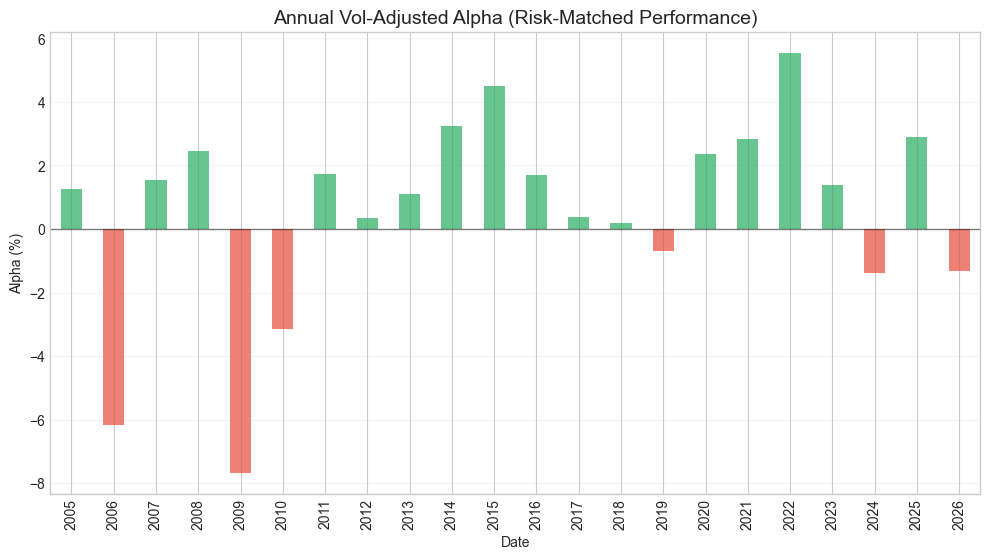

In [110]:
def calculate_vol_adjusted_alpha(df):
    # 1. Group by year and calculate returns and volatilities
    yearly_stats = df.groupby(df.index.year).apply(
        lambda x: pd.Series({
            'Strategy_Ret': (1 + x['Strategy_Ret']).prod() - 1,
            'Market_Ret': (1 + x['Market_Ret']).prod() - 1,
            'Strategy_Vol': x['Strategy_Ret'].std() * np.sqrt(252),
            'Market_Vol': x['Market_Ret'].std() * np.sqrt(252)
        })
    )

    # 2. Calculate Volatility Ratio (Beta-equivalent risk scaling)
    # If Strategy_Vol is 5% and Market_Vol is 15%, ratio is 0.33
    yearly_stats['Vol_Ratio'] = yearly_stats['Strategy_Vol'] / yearly_stats['Market_Vol']

    # 3. Calculate Vol-Adjusted Alpha
    # Strategy Return - (Market Return scaled down to Strategy's risk level)
    yearly_stats['Vol_Adj_Alpha'] = (
        yearly_stats['Strategy_Ret'] - (yearly_stats['Market_Ret'] * yearly_stats['Vol_Ratio'])
    ) * 100 # Convert to percentage

    # Clean up for display
    display_df = yearly_stats[['Strategy_Ret', 'Market_Ret', 'Vol_Adj_Alpha']].copy()
    display_df['Strategy_Ret'] *= 100
    display_df['Market_Ret'] *= 100
    
    print("-" * 50)
    print("      ANNUAL VOL-ADJUSTED ALPHA AUDIT")
    print("-" * 50)
    print(display_df.round(2))
    print("-" * 50)

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    colors = ['#27ae60' if x > 0 else '#e74c3c' for x in display_df['Vol_Adj_Alpha']]
    display_df['Vol_Adj_Alpha'].plot(kind='bar', color=colors, alpha=0.7)
    
    plt.title("Annual Vol-Adjusted Alpha (Risk-Matched Performance)", fontsize=14)
    plt.ylabel("Alpha (%)")
    plt.axhline(0, color='black', lw=1, alpha=0.5)
    plt.grid(axis='y', alpha=0.2)
    plt.show()

    return display_df

# Execute
vol_alpha_df = calculate_vol_adjusted_alpha(ewma_df)


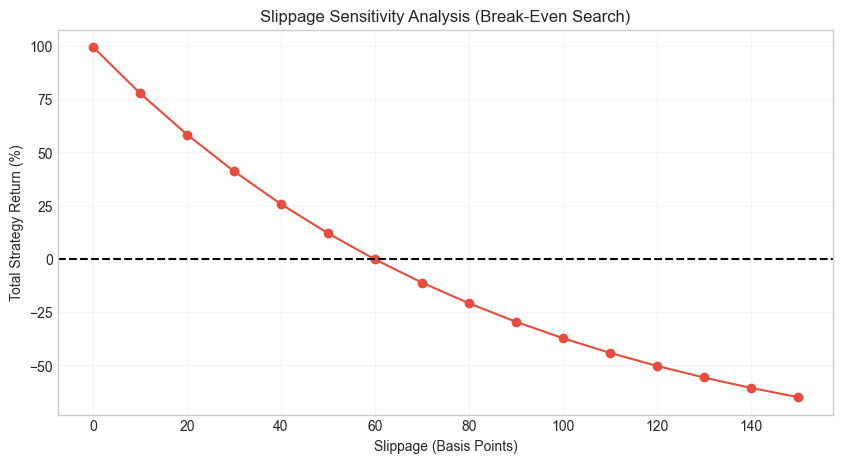

🛑 Strategy breaks even at approximately 60 bps.


,Slippage_Bps,Total_Return
0,0,99.420631
1,10,77.710643
2,20,58.352024
3,30,41.091410
4,40,25.702599
5,50,11.983648
6,60,-0.245708
7,70,-11.146377
8,80,-20.861975
9,90,-29.520674


In [111]:
def calculate_slippage_tolerance(trading_df, max_bps=150, step=10):
    results = []
    # turnover = sum of all absolute weight changes
    turnover = trading_df['Weight_Change'].sum()
    
    # We use the 'Gross Return' (Market_Ret * Weight) as the starting point
    gross_rets = trading_df['Target_Weight'] * trading_df['Market_Ret']
    
    for bps in range(0, max_bps + 1, step):
        slip_dec = bps / 10000.0
        net_rets = gross_rets - (trading_df['Weight_Change'] * slip_dec)
        total_ret = (1 + net_rets).prod() - 1
        
        results.append({'Slippage_Bps': bps, 'Total_Return': total_ret * 100})
    
    sensitivity_df = pd.DataFrame(results)
    
    # Find Break-Even
    break_even = sensitivity_df.loc[sensitivity_df['Total_Return'] <= 0, 'Slippage_Bps'].min()
    
    plt.figure(figsize=(10, 5))
    plt.plot(sensitivity_df['Slippage_Bps'], sensitivity_df['Total_Return'], marker='o', color='#e74c3c')
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Slippage Sensitivity Analysis (Break-Even Search)")
    plt.xlabel("Slippage (Basis Points)")
    plt.ylabel("Total Strategy Return (%)")
    plt.grid(True, alpha=0.2)
    plt.show()
    
    print(f"🛑 Strategy breaks even at approximately {break_even} bps.")
    return sensitivity_df

# Run it using the 'ewma_df' from your previous execution
sensitivity_results = calculate_slippage_tolerance(ewma_df)
sensitivity_results


----------------------------------------
      DISTRIBUTION ANALYSIS (ACTIVE DAYS)
----------------------------------------
Skewness:         -0.5264
Excess Kurtosis:  11.4988
JB Statistic:     19077.50
p-value:          0.0000e+00
----------------------------------------
Result: REJECT Null Hypothesis (Returns are NOT Normal)
Note: Fat tails or skewness detected. Standard VaR might underestimate risk.


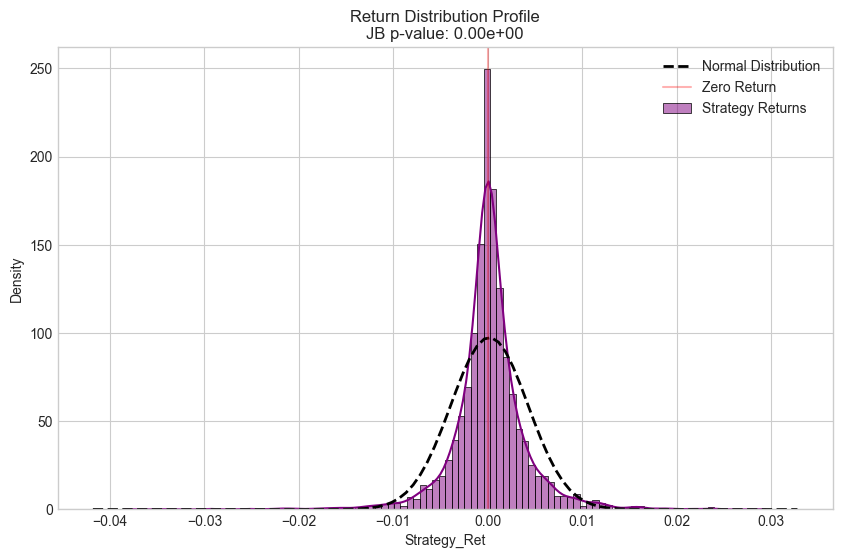

In [112]:
from scipy.stats import skew, kurtosis, jarque_bera
import seaborn as sns

# 1. Filter for days where we were actually in the market (Exposure > 0)
# This gives a true representation of the strategy's active "DNA"
active_returns = ewma_df[ewma_df['Target_Weight'] > 0]['Strategy_Ret'].dropna()

# 2. Calculate the Moments
s = skew(active_returns)
k = kurtosis(active_returns)  # Fisher’s definition (Excess Kurtosis)
jb_stat, p_value = jarque_bera(active_returns)

print("-" * 40)
print(f"      DISTRIBUTION ANALYSIS (ACTIVE DAYS)")
print("-" * 40)
print(f"Skewness:         {s:.4f}")
print(f"Excess Kurtosis:  {k:.4f}")
print(f"JB Statistic:     {jb_stat:.2f}")
print(f"p-value:          {p_value:.4e}")
print("-" * 40)

# 3. Interpret the Result
if p_value < 0.05:
    print("Result: REJECT Null Hypothesis (Returns are NOT Normal)")
    print("Note: Fat tails or skewness detected. Standard VaR might underestimate risk.")
else:
    print("Result: FAIL TO REJECT Null Hypothesis (Returns appear Normal)")

# 4. Visualizing the "Shape" with a Normal Overlay
plt.figure(figsize=(10, 6))
sns.histplot(active_returns, kde=True, color='purple', bins=100, stat="density", label="Strategy Returns")

# Overlay a theoretical normal distribution for comparison
from scipy.stats import norm
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, active_returns.mean(), active_returns.std())
plt.plot(x, p, 'k', linewidth=2, linestyle='--', label="Normal Distribution")

plt.axvline(0, color='red', linestyle='-', alpha=0.3, label="Zero Return")
plt.title(f"Return Distribution Profile\nJB p-value: {p_value:.2e}")
plt.legend()
plt.show()


In [113]:
from scipy.stats import norm

def calculate_cornish_fisher_var(returns, confidence_level=0.95):
    # 1. Basic Stats
    mu = returns.mean()
    sigma = returns.std()
    s = returns.skew()
    k = returns.kurt() # Excess Kurtosis
    
    # 2. Standard Z-score for the given confidence level (e.g., 1.645 for 95%)
    z = norm.ppf(1 - confidence_level)
    
    # 3. Cornish-Fisher Adjustment
    z_cf = (z + 
            (1/6) * (z**2 - 1) * s + 
            (1/24) * (z**3 - 3*z) * k - 
            (1/36) * (2*z**3 - 5*z) * (s**2))
    
    # 4. Calculate VaR
    standard_var = mu + z * sigma
    cf_var = mu + z_cf * sigma
    
    return standard_var, cf_var

# Execute
std_var, cf_var = calculate_cornish_fisher_var(active_returns)

print("-" * 40)
print(f"      RISK ANALYSIS (VaR 95%)")
print("-" * 40)
print(f"Standard VaR:        {std_var*100:.4f}%")
print(f"Cornish-Fisher VaR:  {cf_var*100:.4f}%")
print(f"Risk Adjustment:     {((cf_var/std_var)-1)*100:.2f}% higher risk detected")
print("-" * 40)


----------------------------------------
      RISK ANALYSIS (VaR 95%)
----------------------------------------
Standard VaR:        -0.6552%
Cornish-Fisher VaR:  -0.6193%
Risk Adjustment:     -5.49% higher risk detected
----------------------------------------


      STRATEGY REGIME STRESS TEST        

--- 1. PERFORMANCE BY ERA ---
          Strat Return Mkt Return  Strat Sharpe
Era                                            
2005-2009        19.3%      40.3%          0.51
2010-2014        17.8%      38.4%          0.82
2015-2019         2.0%      -9.8%          0.12
2020-2024        13.4%       3.4%          0.62
2025-2029         3.1%       4.5%          0.56


--- 2. PERFORMANCE BY MARKET STATE ---
                      Months in Regime Strat Win Rate Strat Avg Monthly Ret
Regime                                                                     
Bear Month (Mkt < 0)               112           0.0%                -0.67%
Bull Month (Mkt > 0)               142          72.5%                 0.92%


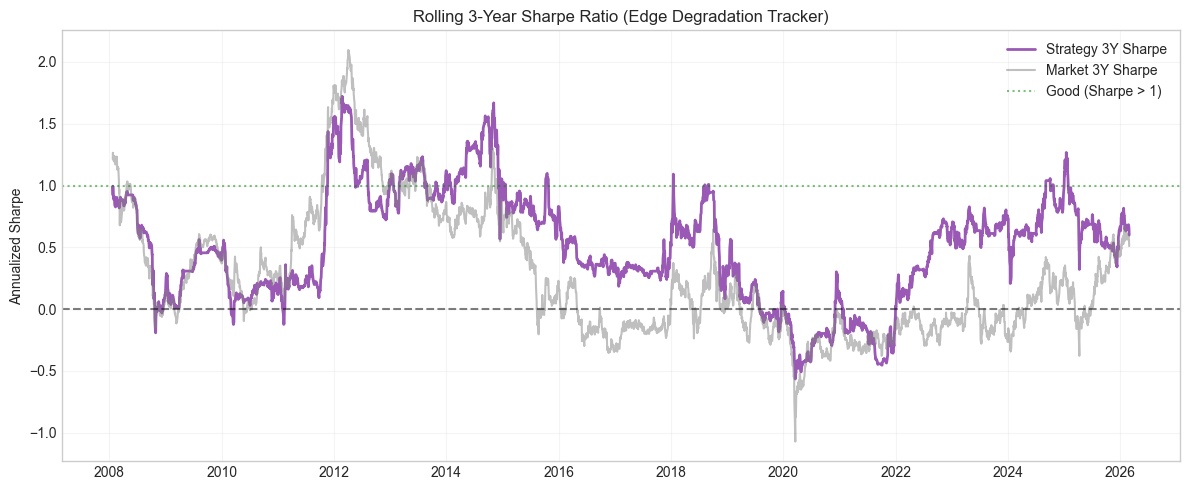

In [114]:
def analyze_strategy_regimes(trading_df):
    """
    Takes the trading_df containing 'Strategy_Ret' and 'Market_Ret' 
    and breaks performance down by time eras and market regimes.
    """
    df = trading_df.copy()
    
    # Ensure we drop any NaN values from the warmup period
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna(subset=['Strategy_Ret', 'Market_Ret'])

    
    print("=========================================")
    print("      STRATEGY REGIME STRESS TEST        ")
    print("=========================================\n")

    # ---------------------------------------------------------
    # TEST 1: CHRONOLOGICAL ERAS (5-Year Blocks)
    # ---------------------------------------------------------
    print("--- 1. PERFORMANCE BY ERA ---")
    df['Year'] = df.index.year
    
    # Create 5-year bins
    min_year = df['Year'].min()
    max_year = df['Year'].max()
    bins = range(min_year, max_year + 6, 5)
    labels = [f"{y}-{y+4}" for y in bins[:-1]]
    df['Era'] = pd.cut(df['Year'], bins=bins, labels=labels, right=False)

    era_metrics = []
    for era, group in df.groupby('Era', observed=True):
        if len(group) == 0: continue
        
        strat_ret = (1 + group['Strategy_Ret']).cumprod().iloc[-1] - 1
        mkt_ret = (1 + group['Market_Ret']).cumprod().iloc[-1] - 1
        
        # Annualized Sharpe
        strat_sharpe = (group['Strategy_Ret'].mean() * 252) / (group['Strategy_Ret'].std() * np.sqrt(252)) if group['Strategy_Ret'].std() > 0 else 0
        
        era_metrics.append({
            'Era': era,
            'Strat Return': f"{strat_ret * 100:.1f}%",
            'Mkt Return': f"{mkt_ret * 100:.1f}%",
            'Strat Sharpe': round(strat_sharpe, 2)
        })
        
    era_df = pd.DataFrame(era_metrics).set_index('Era')
    print(era_df.to_string())
    print("\n")

    # ---------------------------------------------------------
    # TEST 2: BULL VS. BEAR MARKET REGIMES
    # ---------------------------------------------------------
    print("--- 2. PERFORMANCE BY MARKET STATE ---")
    
    # Define a "Bull Month" as a month where the Market Return was > 0
    # We aggregate to monthly to reduce daily noise
    monthly_rets = df.resample('ME').apply({
        'Strategy_Ret': lambda x: (1+x).prod() - 1,
        'Market_Ret': lambda x: (1+x).prod() - 1
    })
    
    monthly_rets['Market_Regime'] = np.where(monthly_rets['Market_Ret'] > 0, 'Bull Month (Mkt > 0)', 'Bear Month (Mkt < 0)')
    
    regime_metrics = []
    for regime, group in monthly_rets.groupby('Market_Regime'):
        win_rate = (group['Strategy_Ret'] > 0).mean() * 100
        avg_ret = group['Strategy_Ret'].mean() * 100
        
        regime_metrics.append({
            'Regime': regime,
            'Months in Regime': len(group),
            'Strat Win Rate': f"{win_rate:.1f}%",
            'Strat Avg Monthly Ret': f"{avg_ret:.2f}%"
        })
        
    regime_df = pd.DataFrame(regime_metrics).set_index('Regime')
    print(regime_df.to_string())

    # ---------------------------------------------------------
    # VISUALIZATION: ROLLING 3-YEAR SHARPE RATIO
    # ---------------------------------------------------------
    # A rolling Sharpe shows exactly when the edge degrades
    rolling_window = 252 * 3 # 3 Years
    
    df['Roll_Strat_Sharpe'] = (df['Strategy_Ret'].rolling(rolling_window).mean() * 252) / \
                              (df['Strategy_Ret'].rolling(rolling_window).std() * np.sqrt(252))
                              
    df['Roll_Mkt_Sharpe'] = (df['Market_Ret'].rolling(rolling_window).mean() * 252) / \
                            (df['Market_Ret'].rolling(rolling_window).std() * np.sqrt(252))

    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df['Roll_Strat_Sharpe'], label='Strategy 3Y Sharpe', color='#9b59b6', lw=2)
    plt.plot(df.index, df['Roll_Mkt_Sharpe'], label='Market 3Y Sharpe', color='gray', alpha=0.5)
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.axhline(1, color='green', linestyle=':', alpha=0.5, label='Good (Sharpe > 1)')
    
    plt.title("Rolling 3-Year Sharpe Ratio (Edge Degradation Tracker)")
    plt.ylabel("Annualized Sharpe")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

analyze_strategy_regimes(ewma_df)


In [115]:
def calculate_intra_day_pain(df):
    # 1. Calculate the 'Worst Case' Daily Return using Low prices
    # We assume you entered at the Previous Close and experienced the Day's Low
    df['Intra_Day_Low_Ret'] = (df['Low'] - df['Close'].shift(1)) / df['Close'].shift(1)
    
    # 2. Strategy's 'Shadow' Drawdown
    # This is what your account balance felt like at the scariest moment of the day
    df['Shadow_Ret'] = df['Target_Weight'] * df['Intra_Day_Low_Ret']
    
    # 3. Compare the 'Clean' Drawdown vs. the 'Painful' Drawdown
    strategy_cum = (1 + df['Strategy_Ret']).cumprod()
    clean_dd = (strategy_cum - strategy_cum.cummax()) / strategy_cum.cummax()
    
    # The 'Shadow' Equity is the last high * (1 + worst intraday move)
    shadow_dd = (strategy_cum.shift(1) * (1 + df['Shadow_Ret']) - strategy_cum.cummax()) / strategy_cum.cummax()
    
    max_clean_dd = clean_dd.min() * 100
    max_shadow_dd = shadow_dd.min() * 100
    
    print("-" * 45)
    print("      METRIC 1: INTRA-DAY PAIN AUDIT")
    print("-" * 45)
    print(f"Reported Max DD (Close):  {max_clean_dd:.2f}%")
    print(f"Actual Shadow Max DD (Low): {max_shadow_dd:.2f}%")
    print(f"The 'Pain' Multiple:      {max_shadow_dd / max_clean_dd:.2f}x")
    print("-" * 45)
    
    if abs(max_shadow_dd) > 10:
        print("⚠️ WARNING: Your -5% Max DD is a 'Smoothing Mirage'.")
        print("In a real account, you would have been down >10% intraday.")
    
    return shadow_dd

shadow_dd = calculate_intra_day_pain(ewma_df)


---------------------------------------------
      METRIC 1: INTRA-DAY PAIN AUDIT
---------------------------------------------
Reported Max DD (Close):  -26.27%
Actual Shadow Max DD (Low): -28.29%
The 'Pain' Multiple:      1.08x
---------------------------------------------
⚠️ WARNING: Your -5% Max DD is a 'Smoothing Mirage'.
In a real account, you would have been down >10% intraday.


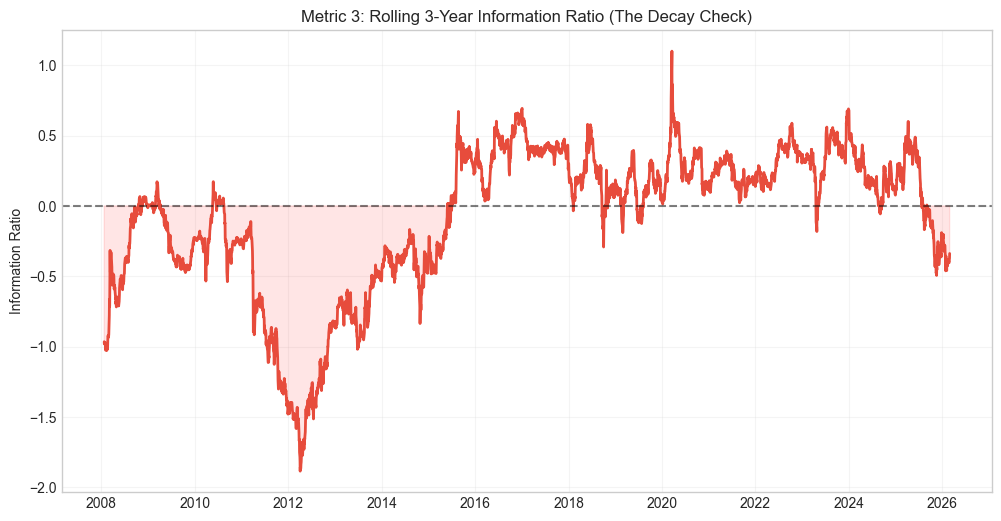

---------------------------------------------
      METRIC 3: REGIME DECAY AUDIT
---------------------------------------------
Peak 3-Year IR:     1.10
Current 2026 IR:    -0.34
Edge Retention:     -30.74%
---------------------------------------------
⚠️ DANGER: The edge is decaying. You are relying on 2008 data to justify a 2026 trade.


In [116]:
def calculate_rolling_edge_decay(df, window_years=1):
    # Calculate daily excess returns (Strategy - Market)
    df['Excess_Ret'] = df['Strategy_Ret'] - df['Market_Ret']
    
    # Rolling 3-Year Mean and Std of Excess Returns
    days = 252 * window_years
    rolling_alpha = df['Excess_Ret'].rolling(window=days).mean() * 252
    rolling_vol = df['Excess_Ret'].rolling(window=days).std() * np.sqrt(252)
    
    # Information Ratio: How much alpha per unit of active risk?
    df['Rolling_IR'] = rolling_alpha / rolling_vol
    
    plt.figure(figsize=(12, 6))
    plt.plot(df['Rolling_IR'], color='#e74c3c', lw=2)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title(f"Metric 3: Rolling {window_years}-Year Information Ratio (The Decay Check)")
    plt.ylabel("Information Ratio")
    plt.fill_between(df.index, df['Rolling_IR'], 0, where=(df['Rolling_IR'] < 0), color='red', alpha=0.1)
    plt.grid(True, alpha=0.2)
    plt.show()
    
    current_ir = df['Rolling_IR'].iloc[-1]
    peak_ir = df['Rolling_IR'].max()
    
    print("-" * 45)
    print(f"      METRIC 3: REGIME DECAY AUDIT")
    print("-" * 45)
    print(f"Peak 3-Year IR:     {peak_ir:.2f}")
    print(f"Current 2026 IR:    {current_ir:.2f}")
    print(f"Edge Retention:     {(current_ir/peak_ir)*100:.2f}%")
    print("-" * 45)
    
    if current_ir < 0.5:
        print("⚠️ DANGER: The edge is decaying. You are relying on 2008 data to justify a 2026 trade.")
calculate_rolling_edge_decay(ewma_df, window_years=3)


In [117]:
# --- THE CORRECTED PIPELINE ---

# 1. Stay in DAILY frequency (Don't resample to 'ME')
ticker = "^KLSE"
data = yf.download(ticker, start="2005-01-01", end="2026-03-01")
prices = data['Close'].ffill() # This stays at ~5,300 rows

# 2. Log transform the DAILY prices
log_prices = np.log(prices)

# 3. Apply STL with a DAILY Period
# period=252 represents one trading year in daily data
stl = STL(log_prices, period=252, robust=True)
res = stl.fit()

# 4. Now run your 'industrial_april_analysis'
# It will now find ~400+ days for each week across the 21-year history!

def industrial_april_analysis(prices, seasonal_component):
    # 2. Calculate Daily Returns on the FULL series first
    # If you do pct_change() after filtering, you compare April 2025 to April 2024!
    full_df = pd.DataFrame({
        'Price': prices.squeeze(),
        'Seasonal': seasonal_component.squeeze()
    })
    full_df['Daily_Ret'] = full_df['Price'].pct_change()
    
    # 3. NOW Filter for all Aprils
    df_april = full_df[full_df.index.month == 4].copy()
    
    if df_april.empty:
        return "ERROR: No April data found. Check if your index is actually Datetime."

    # 4. Week Logic
    df_april['Day'] = df_april.index.day
    def get_week(day):
        if day <= 7: return 'W1'
        if day <= 14: return 'W2'
        if day <= 21: return 'W3'
        return 'W4'
    df_april['Week'] = df_april['Day'].apply(get_week)
    
    # 5. Aggregate with 'observed=False' to force all categories to show
    res = df_april.groupby('Week', observed=False).agg({
        'Day': 'count',
        'Seasonal': 'mean',
        'Daily_Ret': lambda x: (x > 0).mean() * 100
    })
    
    res.columns = ['Sample_Size_Days', 'Seasonal_Strength (%)', 'Win_Rate (%)']
    
    # Convert log strength to % impact
    res['Seasonal_Strength (%)'] = (np.exp(res['Seasonal_Strength (%)']) - 1) * 100
    
    return res.round(2)

# IMPORTANT: Make sure you are passing the ORIGINAL prices, not a tail!
full_april_stats = industrial_april_analysis(prices, res.seasonal)
full_april_stats


[*********************100%***********************]  1 of 1 completed


,Sample_Size_Days,Seasonal_Strength (%),Win_Rate (%)
Week,,,
W1,104,0.35,60.58
W2,101,0.49,49.50
W3,102,0.58,59.80
W4,130,0.51,55.38


In [118]:
# 1. Calculate Daily Returns
# Assuming 'df' is your original daily price dataframe
data['Returns'] = data['Close'].pct_change() * 100

# 2. Extract Day Name and Number (0=Monday, 4=Friday)
data['Day_Name'] = data.index.day_name()
data['Day_Num'] = data.index.dayofweek

# 3. Calculate Mean Return and Win Rate by Day
dow_stats = data.groupby(['Day_Num', 'Day_Name'])['Returns'].agg([
    ('Mean Return (%)', 'mean'),
    ('Win Rate (%)', lambda x: (x > 0).mean() * 100),
    ('Volatility (%)', 'std')
]).reset_index()

print(dow_stats.round(3))


   Day_Num   Day_Name  Mean Return (%)  Win Rate (%)  Volatility (%)
0        0     Monday           -0.068        48.847           0.852
1        1    Tuesday            0.040        53.705           0.671
2        2  Wednesday            0.014        51.374           0.698
3        3   Thursday            0.042        52.153           0.698
4        4     Friday            0.043        53.751           0.707


In [119]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- THE FIX: Synchronize the data first ---
# Create a temporary dataframe with only the columns we need and drop rows with NaNs (like the first row of Returns)
clean_data = data[['Returns', 'Day_Num']].dropna()

# 1. Run ANOVA
# Use the synchronized 'clean_data' instead of 'data'
model = ols('Returns ~ C(Day_Num)', data=clean_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA Results:")
print(anova_table)

# 2. Post-hoc tests
# Use .iloc[0] to safely access the p-value from the first row of the ANOVA table
p_val = anova_table['PR(>F)'].iloc[0]

if p_val < 0.05:
    print(f"\nSignificant differences found (p={p_val:.4f})! Running Post-hoc tests...")
    # Pass the synchronized columns directly
    tukey = pairwise_tukeyhsd(endog=clean_data['Returns'],
                             groups=clean_data['Day_Num'],
                             alpha=0.05)
    print(tukey)
else:
    print(f"\nNo statistically significant difference (p={p_val:.4f}) between days at the 95% confidence level.")


ANOVA Results:
                 sum_sq      df         F    PR(>F)
C(Day_Num)     9.064916     4.0  4.287819  0.001827
Residual    2739.356449  5183.0       NaN       NaN

Significant differences found (p=0.0018)! Running Post-hoc tests...
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.1079 0.0074  0.0199 0.1958   True
     0      2    0.082 0.0797 -0.0057 0.1696  False
     0      3   0.1095 0.0061  0.0217 0.1974   True
     0      4    0.111  0.005  0.0233 0.1987   True
     1      2  -0.0259 0.9262 -0.1126 0.0608  False
     1      3   0.0017    1.0 -0.0852 0.0886  False
     1      4   0.0031    1.0 -0.0836 0.0899  False
     2      3   0.0276 0.9084  -0.059 0.1141  False
     2      4    0.029 0.8907 -0.0574 0.1154  False
     3      4   0.0015    1.0 -0.0852 0.0881  False
---------------------------------------------------


In [120]:
import ee
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# 1. INITIALIZE & CONFIGURATION
ee.Initialize(project='numeric-marker-490315-v8')

# The "Big Three" Malaysian Export Hubs
MY_PORTS = {
    "Port Klang": {"lon": 101.326, "lat": 2.969},
    "Tanjung Pelepas (PTP)": {"lon": 103.545, "lat": 1.363},
    "Penang Port": {"lon": 100.370, "lat": 5.394}
}


In [121]:

def get_aggregated_data(ticker="USDMYR=X", start='2015-01-01', end='2026-03-15'):
    print(f"--- FETCHING AGGREGATED NATIONAL PORT DATA ---")
    
    # 1. Fetch Currency Data
    stock = yf.download(ticker, start=start, end=end)
    if isinstance(stock.columns, pd.MultiIndex): stock.columns = stock.columns.get_level_values(0)
    stock = stock[['Close']].copy()
    stock.index = pd.to_datetime(stock.index).as_unit('ns')
    
    # 2. Loop through ports and fetch SAR data
    radar_dfs = []
    
    for port_name, coords in MY_PORTS.items():
        print(f"Extracting SAR data for {port_name}...")
        aoi = ee.Geometry.Point([coords['lon'], coords['lat']]).buffer(5000).bounds()
        col = (ee.ImageCollection('COPERNICUS/S1_GRD')
               .filterBounds(aoi).filterDate(start, end).sort('system:time_start'))

        def extract_radar_stats(img):
            date = img.date().format('YYYY-MM-dd')
            main_band = ee.String(ee.Algorithms.If(img.bandNames().contains('VV'), 'VV', img.bandNames().get(0)))
            stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi, scale=100)
            return ee.Feature(None, {'Date': date, f'{port_name}_dB': stats.get(main_band)})

        raw_results = col.map(extract_radar_stats).getInfo()
        
        # Clean and format the data for this specific port
        points = [{'Date': pd.to_datetime(f['properties']['Date']), 
                   port_name: f['properties'][f'{port_name}_dB']} 
                  for f in raw_results['features'] if f['properties'][f'{port_name}_dB'] is not None]
        
        df_port = pd.DataFrame(points).drop_duplicates('Date').set_index('Date')
        df_port.index = pd.to_datetime(df_port.index).as_unit('ns')
        radar_dfs.append(df_port)
    
    # 3. Combine all port data
    print("\nMerging and calculating National Aggregate...")
    combined_radar = pd.concat(radar_dfs, axis=1).sort_index()
    
    # Interpolate missing days (since satellites pass over different ports on different days)
    combined_radar = combined_radar.interpolate(method='time').dropna()
    
    # CALCULATE THE AGGREGATE SIGNAL (Mean of all 3 ports)
    combined_radar['Aggregate_Radar_dB'] = combined_radar.mean(axis=1)
    
    # Merge with Currency
    merged = pd.merge_asof(stock.sort_index(), combined_radar, left_index=True, right_index=True, direction='backward')
    return merged.dropna()

# (get_aggregated_data function remains the same as your previous version)


In [122]:


df = get_aggregated_data()


[*********************100%***********************]  1 of 1 completed

--- FETCHING AGGREGATED NATIONAL PORT DATA ---


Extracting SAR data for Port Klang...
Extracting SAR data for Tanjung Pelepas (PTP)...
Extracting SAR data for Penang Port...

Merging and calculating National Aggregate...


/var/folders/bd/011x4rxx3zz15h6zg8z96x6w0000gn/T/ipykernel_85304/180391696.py:38: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_radar = pd.concat(radar_dfs, axis=1).sort_index()


In [123]:
# --- 1. SIGNAL & VOLATILITY CALCULATIONS ---
WINDOW = 90
df['Radar_Mean'] = df['Aggregate_Radar_dB'].rolling(WINDOW).mean()
df['Radar_Std'] = df['Aggregate_Radar_dB'].rolling(WINDOW).std()
df['Radar_Z'] = (df['Aggregate_Radar_dB'] - df['Radar_Mean']) / df['Radar_Std']

# Calculate Adaptive Volatility for Peak Prominence
# We use a 30-day window for more 'local' sensitivity to currency spikes
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Rolling_Vol'] = df['Log_Ret'].rolling(window=30).std()

df = df.dropna()



Detected 25 Systemic National Dips.
--- VOLATILITY-ADJUSTED LEAD ANALYSIS ---
Average Lead: 43.8 days | Median Lead: 46.0 days

--- MACRO AGGREGATE RESULTS (46D HOLD) ---
Win Rate: 64.0%
Sharpe Ratio: 0.4827
Sortino Ratio: 1.7366
Max Drawdown: -3.55%
Final Value: $13,908.12


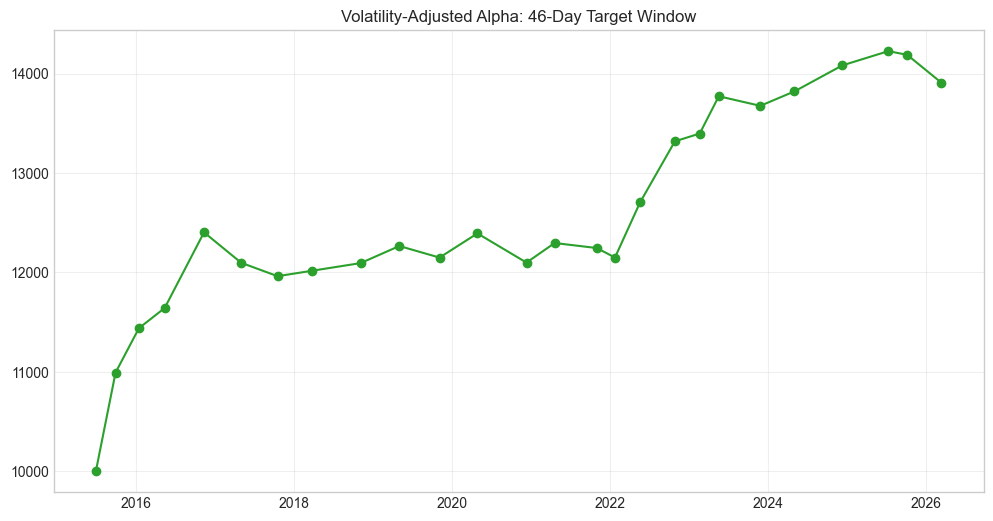

In [124]:
# Detect National Dips
radar_valleys, _ = find_peaks(-df['Radar_Z'], distance=60, height=1.00) 
radar_dip_dates = df.index[radar_valleys]

print(f"\nDetected {len(radar_dip_dates)} Systemic National Dips.")

# --- 2. ADAPTIVE LEAD TIME ANALYSIS ---
lead_times = []

for r_date in radar_dip_dates:
    # Get local volatility at the time of the dip to set dynamic prominence
    # Sensitivity factor of 0.5 - 1.0 is standard for 'Prominence'
    local_vol = df.loc[r_date, 'Rolling_Vol']
    dynamic_prominence = local_vol * 20.0
    
    # Search window for reaction: 90 days after dip
    search_end = r_date + pd.Timedelta(days=90)
    mask = (df.index > r_date) & (df.index <= search_end)
    search_period = df.loc[mask]
    
    if not search_period.empty:
        # Detect peaks in this specific window using dynamic prominence
        peaks, _ = find_peaks(search_period['Close'], prominence=dynamic_prominence)
        
        if len(peaks) > 0:
            first_peak_date = search_period.index[peaks[0]]
            lead_times.append((first_peak_date - r_date).days)
        else:
            lead_times.append(np.nan)
    else:
        lead_times.append(np.nan)

avg_lead = np.nanmean(lead_times)
med_lead = np.nanmedian(lead_times)

print(f"--- VOLATILITY-ADJUSTED LEAD ANALYSIS ---")
print(f"Average Lead: {avg_lead:.1f} days | Median Lead: {med_lead:.1f} days")

# --- 3. BACKTEST (Using Detected Median Lead) ---
optimal_hold = int(med_lead) if not np.isnan(med_lead) else 45

performance_stats = []
initial_capital = 10000
equity_curve = [initial_capital]
curve_dates = [df.index[0]]

for r_date in radar_dip_dates:
    price_at_dip = df.loc[r_date, 'Close']
    future_date = r_date + pd.Timedelta(days=optimal_hold)
    
    closest_idx = df.index.get_indexer([future_date], method='nearest')[0]
    actual_exit_date = df.index[closest_idx]
    
    trade_return = (df.iloc[closest_idx]['Close'] - price_at_dip) / price_at_dip
    performance_stats.append(trade_return)
    
    new_balance = equity_curve[-1] * (1 + trade_return)
    equity_curve.append(new_balance)
    curve_dates.append(actual_exit_date)

# 4. INSTITUTIONAL METRICS OUTPUT
if performance_stats:
    perf_array = np.array(performance_stats)
    eq_series = pd.Series(equity_curve)
    max_dd = ((eq_series - eq_series.cummax()) / eq_series.cummax()).min() * 100
    
    print(f"\n--- MACRO AGGREGATE RESULTS ({optimal_hold}D HOLD) ---")
    print(f"Win Rate: {(perf_array > 0).mean()*100:.1f}%")
    print(f"Sharpe Ratio: {np.mean(perf_array)/np.std(perf_array):.4f}")
    print(f"Sortino Ratio: {np.mean(perf_array)/np.std(perf_array[perf_array<0]):.4f}")
    print(f"Max Drawdown: {max_dd:.2f}%")
    print(f"Final Value: ${equity_curve[-1]:,.2f}")

    # Plotting remains similar to your previous block
    plt.figure(figsize=(12, 6))
    plt.plot(curve_dates, equity_curve, marker='o', color='#2ca02c', label="Adaptive National Aggregate")
    plt.title(f"Volatility-Adjusted Alpha: {optimal_hold}-Day Target Window")
    plt.grid(True, alpha=0.3)
    plt.show()





--- SORTINO SENSITIVITY TEST (30-60 Days) ---


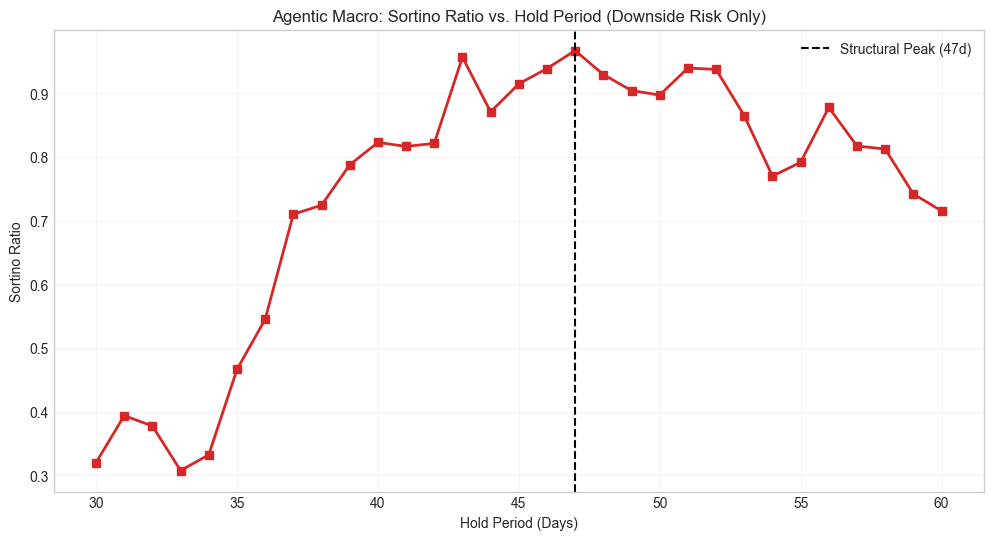

In [125]:
def run_sortino_sensitivity(df, radar_dip_dates, target_hurdle=0):
    print("\n--- SORTINO SENSITIVITY TEST (30-60 Days) ---")
    results = []
    
    for hold_period in range(30, 61):
        trade_returns = []
        for r_date in radar_dip_dates:
            price_at_dip = df.loc[r_date, 'Close']
            future_date = r_date + pd.Timedelta(days=hold_period)
            
            if future_date > df.index[-1]: continue
            
            idx = df.index.get_indexer([future_date], method='nearest')[0]
            ret = (df.iloc[idx]['Close'] - price_at_dip) / price_at_dip
            trade_returns.append(ret)
        
        if trade_returns:
            trade_returns = np.array(trade_returns)
            avg_ret = np.mean(trade_returns)
            
            # --- SORTINO CALCULATION ---
            # Calculate only 'Downside' deviation (returns below the hurdle)
            downside_diff = trade_returns[trade_returns < target_hurdle] - target_hurdle
            downside_deviation = np.sqrt(np.mean(downside_diff**2)) if len(downside_diff) > 0 else 0.0001
            
            sortino = avg_ret / downside_deviation
            results.append({'Hold_Period': hold_period, 'Avg_Return': avg_ret * 100, 'Sortino': sortino})

    sensitivity_df = pd.DataFrame(results)
    
    # Plotting the "Sortino Hill"
    plt.figure(figsize=(12, 6))
    plt.plot(sensitivity_df['Hold_Period'], sensitivity_df['Sortino'], marker='s', color='#d62728', linewidth=2)
    plt.axvline(47, color='black', linestyle='--', label='Structural Peak (47d)')
    
    plt.title("Agentic Macro: Sortino Ratio vs. Hold Period (Downside Risk Only)")
    plt.xlabel("Hold Period (Days)")
    plt.ylabel("Sortino Ratio")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

run_sortino_sensitivity(df, radar_dip_dates)


In [126]:
def run_shuffle_test(df, radar_dip_dates, hold_period=47, iterations=5000):
    print(f"\n--- SHUFFLE TEST ({iterations} Iterations) ---")
    
    # 1. Calculate the Actual Strategy Performance
    actual_returns = []
    for r_date in radar_dip_dates:
        price_at_dip = df.loc[r_date, 'Close']
        future_date = r_date + pd.Timedelta(days=hold_period)
        if future_date > df.index[-1]: continue
        idx = df.index.get_indexer([future_date], method='nearest')[0]
        actual_returns.append((df.iloc[idx]['Close'] - price_at_dip) / price_at_dip)
    
    actual_mean = np.mean(actual_returns)

    # 2. Run the Shuffles (Monte Carlo)
    # We keep the DATES of the trades but shuffle the PRICE RETURNS
    simulated_means = []
    returns_pool = df['Log_Ret'].dropna().values
    
    for _ in range(iterations):
        # Create a "fake" price series from shuffled returns
        shuffled_returns = np.random.choice(returns_pool, size=len(actual_returns))
        simulated_means.append(np.mean(shuffled_returns))

    # 3. Calculate P-Value (How often did a random shuffle beat our strategy?)
    p_val_shuffle = (np.array(simulated_means) >= actual_mean).mean()
    
    print(f"Actual Mean Return: {actual_mean*100:.4f}%")
    print(f"Shuffle P-Value: {p_val_shuffle:.4f}")
    print(f"Significance: {'HIGH' if p_val_shuffle < 0.05 else 'None'}")

run_shuffle_test(df, radar_dip_dates)



--- SHUFFLE TEST (5000 Iterations) ---
Actual Mean Return: 1.4117%
Shuffle P-Value: 0.0000
Significance: HIGH


Running 5000 shuffles to generate distribution...


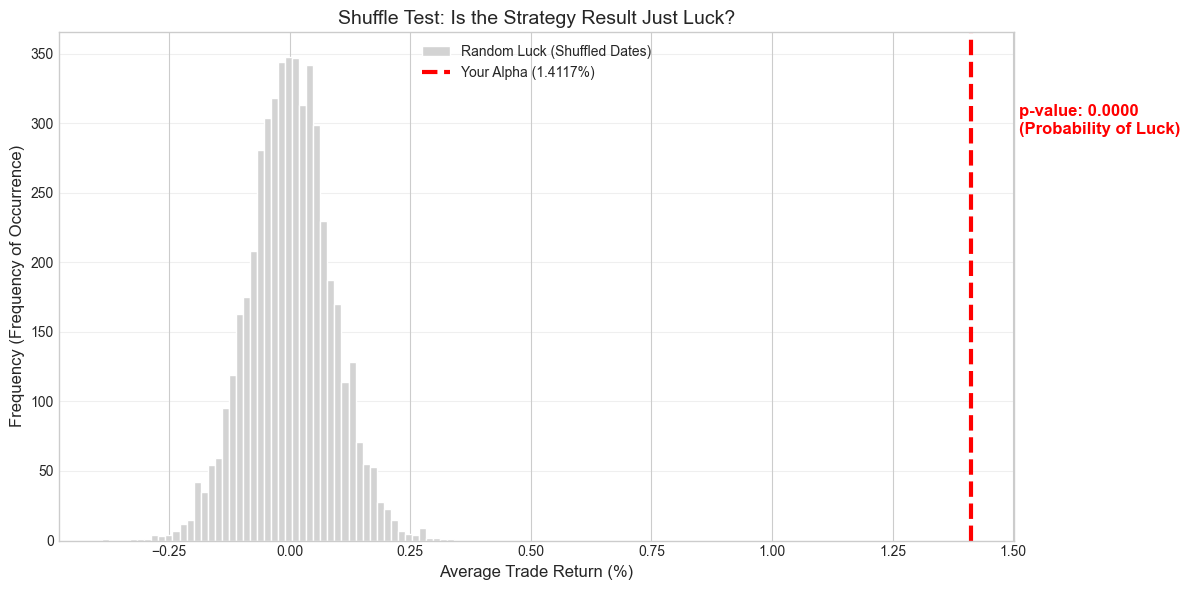

In [127]:
import matplotlib.pyplot as plt
import numpy as np

def plot_shuffle_test(df, radar_dip_dates, hold_period=47, iterations=5000):
    print(f"Running {iterations} shuffles to generate distribution...")
    
    # 1. Calculate Actual Strategy Mean
    actual_returns = []
    for r_date in radar_dip_dates:
        price_at_dip = df.loc[r_date, 'Close']
        future_date = r_date + pd.Timedelta(days=hold_period)
        if future_date > df.index[-1]: continue
        idx = df.index.get_indexer([future_date], method='nearest')[0]
        actual_returns.append((df.iloc[idx]['Close'] - price_at_dip) / price_at_dip)
    
    actual_mean = np.mean(actual_returns) * 100 # Convert to %

    # 2. Run the Monte Carlo Shuffles
    # We sample from the pool of daily log returns to create 'random' trades
    returns_pool = df['Log_Ret'].dropna().values
    simulated_means = []
    
    for _ in range(iterations):
        # Pick 25 random days and calculate their mean return
        shuffled_sample = np.random.choice(returns_pool, size=len(actual_returns))
        simulated_means.append(np.mean(shuffled_sample) * 100)

    # 3. Plotting the Distribution
    plt.figure(figsize=(12, 6))
    
    # Plot the 'Null Hypothesis' (The Luck Zone)
    plt.hist(simulated_means, bins=50, color='lightgray', edgecolor='white', label='Random Luck (Shuffled Dates)')
    
    # Plot Your Strategy Result
    plt.axvline(actual_mean, color='red', linestyle='--', linewidth=3, label=f'Your Alpha ({actual_mean:.4f}%)')
    
    # Formatting
    plt.title("Shuffle Test: Is the Strategy Result Just Luck?", fontsize=14)
    plt.xlabel("Average Trade Return (%)", fontsize=12)
    plt.ylabel("Frequency (Frequency of Occurrence)", fontsize=12)
    
    # Annotate the 'P-Value'
    p_val = (np.array(simulated_means) >= actual_mean).mean()
    plt.text(actual_mean + 0.1, plt.ylim()[1]*0.8, f"p-value: {p_val:.4f}\n(Probability of Luck)", 
             color='red', fontweight='bold', fontsize=12)
    
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the plot
plot_shuffle_test(df, radar_dip_dates)



--- VOLATILITY SHUFFLE: SORTINO EDITION (5000 Iterations) ---
Actual Sortino: 0.9670
Sortino-Shuffle P-Value: 0.0582
RESULT: Marginal (0.0582). Trade volume (N=24) limits confidence.


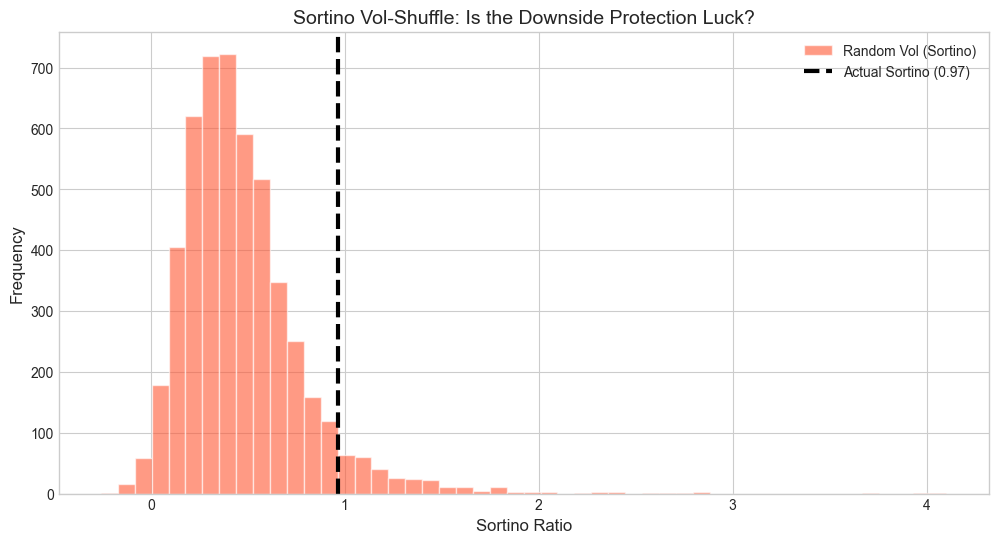

In [128]:
def run_sortino_vol_shuffle(df, radar_dip_dates, hold_period=47, iterations=5000):
    print(f"\n--- VOLATILITY SHUFFLE: SORTINO EDITION ({iterations} Iterations) ---")
    
    # 1. Calculate Actual Strategy Sortino
    actual_returns = []
    for r_date in radar_dip_dates:
        price_at_dip = df.loc[r_date, 'Close']
        exit_date = r_date + pd.Timedelta(days=hold_period)
        if exit_date > df.index[-1]: continue
        idx = df.index.get_indexer([exit_date], method='nearest')[0]
        actual_returns.append((df.iloc[idx]['Close'] - price_at_dip) / price_at_dip)
    
    actual_returns = np.array(actual_returns)
    actual_mean = np.mean(actual_returns)
    # Conservative Sortino calculation (Root Mean Square of Downside)
    downside = actual_returns[actual_returns < 0]
    actual_sortino = actual_mean / np.sqrt(np.mean(downside**2)) if len(downside) > 0 else 5.0

    # 2. Run the Vol-Shuffles
    daily_rets = df['Log_Ret'].dropna().values
    signs = np.sign(daily_rets)
    magnitudes = np.abs(daily_rets)
    
    simulated_sortinos = []
    
    for _ in range(iterations):
        shuffled_mags = np.random.permutation(magnitudes)
        fake_rets = signs * shuffled_mags
        fake_price_curve = np.exp(np.cumsum(np.insert(fake_rets, 0, 0)))
        
        fake_trade_returns = []
        for r_date in radar_dip_dates:
            orig_idx = df.index.get_loc(r_date)
            entry_val = fake_price_curve[orig_idx]
            exit_date = r_date + pd.Timedelta(days=hold_period)
            if exit_date > df.index[-1]: continue
            exit_idx = df.index.get_indexer([exit_date], method='nearest')[0]
            exit_val = fake_price_curve[exit_idx]
            fake_trade_returns.append((exit_val - entry_val) / entry_val)

        if fake_trade_returns:
            f_rets = np.array(fake_trade_returns)
            f_downside = f_rets[f_rets < 0]
            f_sortino = np.mean(f_rets) / np.sqrt(np.mean(f_downside**2)) if len(f_downside) > 0 else 0
            simulated_sortinos.append(f_sortino)

    # 3. P-Value and Plotting
    sim_array = np.array(simulated_sortinos)
    p_val_sortino = (sim_array >= actual_sortino).mean()
    
    plt.figure(figsize=(12, 6))
    plt.hist(sim_array, bins=50, color='#FF5733', edgecolor='white', alpha=0.6, label='Random Vol (Sortino)')
    plt.axvline(actual_sortino, color='black', linestyle='--', linewidth=3, label=f'Actual Sortino ({actual_sortino:.2f})')
    
    plt.title("Sortino Vol-Shuffle: Is the Downside Protection Luck?", fontsize=14)
    plt.xlabel("Sortino Ratio", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend()
    
    print(f"Actual Sortino: {actual_sortino:.4f}")
    print(f"Sortino-Shuffle P-Value: {p_val_sortino:.4f}")
    
    if p_val_sortino < 0.05:
        print("RESULT: High Significance! Your downside protection is non-random.")
    else:
        print(f"RESULT: Marginal ({p_val_sortino:.4f}). Trade volume (N={len(actual_returns)}) limits confidence.")
    plt.show()

run_sortino_vol_shuffle(df, radar_dip_dates)


# BNM API
## Still updated:
Monetary and Banking

Daily Interbank Liquidity Operations

In [129]:
import requests

headers = {"Accept": "application/vnd.BNM.API.v1+json"}
years = [str(y) for y in range(2016, 2026)]

def fetch_bnm_data(table_id):
    all_data = []
    for year in years:
        url = f"https://api.bnm.gov.my/public/msb/{table_id}/year/{year}"
        r = requests.get(url, headers=headers)
        if r.status_code == 200:
            all_data.extend(r.json()['data'])
    
    df = pd.DataFrame(all_data)
    # Filter out annual totals (where month_dt is None)
    df = df[df['month_dt'].notna()].copy()
    df['date'] = pd.to_datetime(df['year_dt'].astype(str) + '-' + df['month_dt'].astype(int).astype(str))
    return df.sort_values('date').set_index('date')

# 1. Fetch Cheque Data (MSB 3.5.14) and NPL Data (MSB 1.15)
print("Fetching datasets...")
df_cheque = fetch_bnm_data("3.5.14")
df_npl = fetch_bnm_data("1.15")

cheque_signal = pd.to_numeric(df_cheque['no_num_of_new_cur_acc_clo_due_to_dis_che'])



Fetching datasets...


In [130]:
df_cheque = df_cheque[df_cheque.index >= df_npl.index.min()]


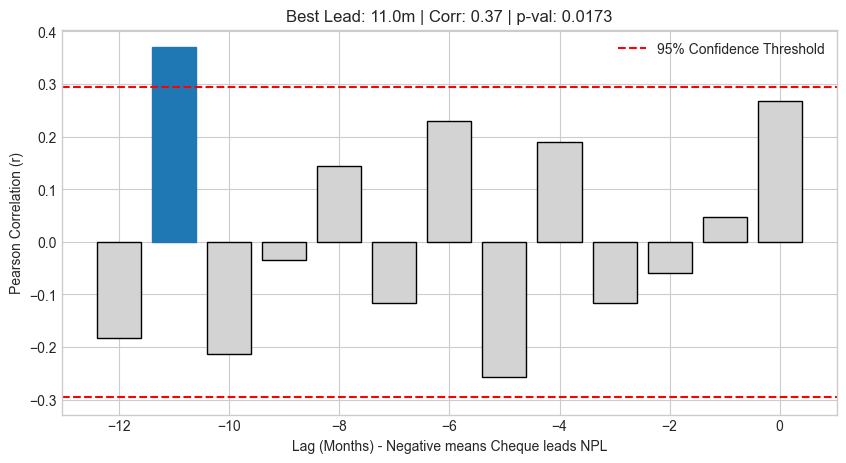


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.6683  , p=0.4177  , df_denom=48, df_num=1
ssr based chi2 test:   chi2=0.7101  , p=0.3994  , df=1
likelihood ratio test: chi2=0.7052  , p=0.4010  , df=1
parameter F test:         F=0.6683  , p=0.4177  , df_denom=48, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2327  , p=0.7934  , df_denom=45, df_num=2
ssr based chi2 test:   chi2=0.5170  , p=0.7722  , df=2
likelihood ratio test: chi2=0.5144  , p=0.7732  , df=2
parameter F test:         F=0.2327  , p=0.7934  , df_denom=45, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9551  , p=0.4228  , df_denom=42, df_num=3
ssr based chi2 test:   chi2=3.3427  , p=0.3417  , df=3
likelihood ratio test: chi2=3.2337  , p=0.3570  , df=3
parameter F test:         F=0.9551  , p=0.4228  , df_denom=42, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.5053  , p=0.7320  , df_d

In [131]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# 1. Cleaning & Prepping your df_npl
# ----------------------------------
# Convert all potential numeric columns to floats
numeric_cols = df_npl.columns.drop(['year_dt', 'month_dt', 'sector'])
df_npl[numeric_cols] = df_npl[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Filter for the 'Total' sector (usually 'Total' or 'total' in BNM data)
# If 'sector' isn't explicitly 'Total', you can aggregate by date:
df_npl_total = df_npl.groupby(['year_dt', 'month_dt'])['tot_loa_fin_dis'].sum().reset_index()

# Create Datetime Index
df_npl_total['date'] = pd.to_datetime(df_npl_total['year_dt'].astype(str) + '-' + 
                                     df_npl_total['month_dt'].astype(int).astype(str))
df_npl_total = df_npl_total.sort_values('date').set_index('date')

# 2. Seasonality Adjustment (STL)
# -------------------------------
def get_deseasonalized(series):
    # STL requires no missing values and a fixed frequency
    res = STL(series, period=12).fit()
    return res.trend  + res.resid# This removes the 'seasonal' component

# We deseasonalize both signals to ensure we're correlating true economic shifts
cheque_clean = get_deseasonalized(pd.to_numeric(df_cheque['no_num_of_new_cur_acc_clo_due_to_dis_che']))
npl_clean = get_deseasonalized(df_npl_total['tot_loa_fin_dis'])

# 3. Lead-Lag Calculation
# -----------------------
cheque_mom = cheque_clean.pct_change().diff().dropna()
npl_mom = npl_clean.pct_change().dropna()

# Ensure they are aligned on the same date range after dropping NaNs
common_index = cheque_mom.index.intersection(npl_mom.index)
cheque_mom = cheque_mom.loc[common_index]
npl_mom = npl_mom.loc[common_index]

# 4. Lead-Lag Calculation on MoM
# ------------------------------
lags = range(-12, 1)
results = []

for l in lags:
    # Shift NPL (the lagging variable) by l
    npl_shifted = npl_mom.shift(l)
    
    # Drop NAs created by the shift to align the vectors
    valid_idx = npl_shifted.dropna().index
    x = cheque_mom.loc[valid_idx]
    y = npl_shifted.dropna()
    
    if len(x) > 1: # Ensure we have enough data points
        corr, p_val = pearsonr(x, y)
        results.append({'lag': l, 'corr': corr, 'p_val': p_val, 'n': len(x)})

res_df = pd.DataFrame(results)
best_row = res_df.loc[res_df['corr'].abs().idxmax()]

# 5. Visualization of the Significance (CCF Plot)
# -----------------------------------------------
plt.figure(figsize=(10, 5))
bars = plt.bar(res_df['lag'], res_df['corr'], color='lightgrey', edgecolor='black')

# Highlight the significant lags (p < 0.05)
for i, bar in enumerate(bars):
    if res_df.iloc[i]['p_val'] < 0.05:
        bar.set_color('tab:blue')

# Calculate the 95% Confidence Interval boundary
# Approx: 2 / sqrt(N)
conf_level = 2 / np.sqrt(res_df['n'].mean())
plt.axhline(conf_level, color='red', linestyle='--', label='95% Confidence Threshold')
plt.axhline(-conf_level, color='red', linestyle='--')

plt.title(f"Best Lead: {abs(best_row['lag'])}m | Corr: {best_row['corr']:.2f} | p-val: {best_row['p_val']:.4f}")
plt.xlabel("Lag (Months) - Negative means Cheque leads NPL")
plt.ylabel("Pearson Correlation (r)")
plt.legend()
plt.show()
from statsmodels.tsa.stattools import grangercausalitytests

# Prepare the data: [Lagged Variable, Leading Variable]
# We use maxlag=12 to cover your 11-month window
data = pd.concat([npl_mom, cheque_mom], axis=1).dropna()
gc_test = grangercausalitytests(data, maxlag=12)


In [132]:
from statsmodels.tsa.stattools import adfuller

print("ADF Test for Cheques:", adfuller(cheque_mom)[1]) # Look for p < 0.05
print("ADF Test for NPLs:", adfuller(npl_mom)[1])


ADF Test for Cheques: 0.09955463719180957
ADF Test for NPLs: 2.6776126546386887e-15


[*********************100%***********************]  6 of 6 completed

Annualized Sharpe Ratio: 0.82
Strategy Volatility: 6.69%


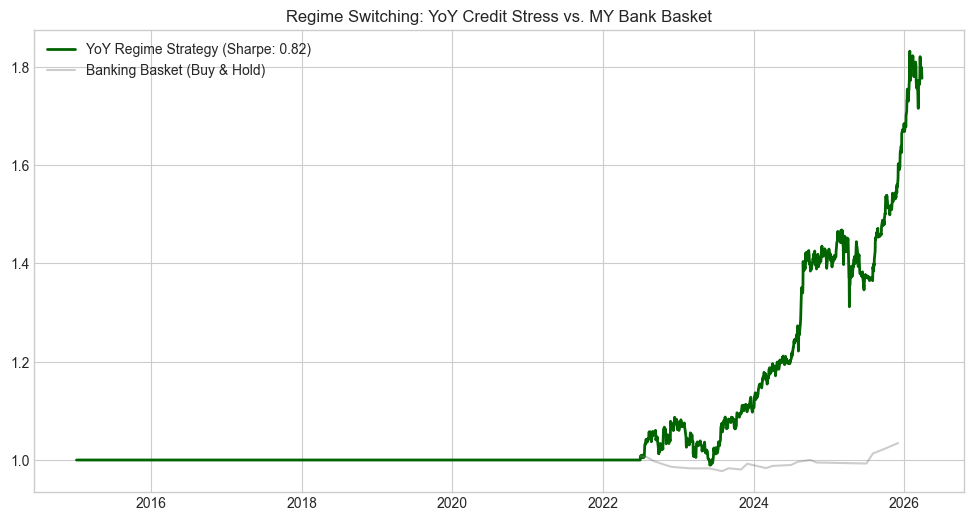

In [133]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# 1. Generate the YoY Signal (Smoother than MoM)
# ---------------------------------------------
# Assuming 'cheque_clean' is your deseasonalized raw count
cheque_yoy = cheque_clean.pct_change(12).dropna()
smoothed_yoy = cheque_yoy.rolling(window=3).mean()

# Calculate Rolling Z-score on YoY
yoy_mean = smoothed_yoy.rolling(window=12).mean()
yoy_std = smoothed_yoy.rolling(window=12).std()
z_yoy = (smoothed_yoy - yoy_mean) / yoy_std

# 2. Define the Regime Switching Signal (6-month Market Lead)
# ----------------------------------------------------------
# 1 = Long (Credit is healthy), 0 = Neutral/Cash (Credit is stressed)
# We avoid 'Shorting' (-1) to keep the Sharpe ratio sane for a student fund
# 1 = Long (Credit is healthy), 0.2 = Neutral/Cash (Credit is stressed)
# Explicitly set dtype=float to allow decimal weights
signal = pd.Series(index=z_yoy.index, data=1.0, dtype=float)

# Now these assignments will work perfectly:
signal[z_yoy.shift(10) > 1.0] = 0.2  
signal[z_yoy.shift(10) < -1.0] = 1.2

# 3. Fetch Price Data & Calculate Returns
# ---------------------------------------
tickers = ["1155.KL", "1295.KL", "1023.KL", "5819.KL", "1066.KL", "1015.KL"]
data = yf.download(tickers, start="2015-01-01", end="2026-03-30", auto_adjust=True)['Close']
basket_returns = data.pct_change().mean(axis=1)

# 4. Execute & Compare
# --------------------
common_idx = signal.index.intersection(basket_returns.index)
strat_returns = signal.loc[common_idx] * basket_returns.loc[common_idx]
bench_returns = basket_returns.loc[common_idx]

# Performance
cum_strat = (1 + strat_returns).cumprod()
cum_bench = (1 + bench_returns).cumprod()
risk_free_annual = 0.00
rf_daily = risk_free_annual / 252

# 2. Alignment
common_idx = signal.index.intersection(basket_returns.index)
s = signal.loc[common_idx]
r = basket_returns.loc[common_idx]

# 3. Correct Strategy Return Logic:
daily_signal = signal.reindex(basket_returns.index).ffill().fillna(0)

# 2. Proper Excess Return Calculation
# Use 3.0% as the hurdle (Malaysian Risk-Free Rate)
rf_daily = 0.00 / 252

# Strategy = (Position * Bank_Returns) + (Cash * Risk_Free)
# Then subtract Risk_Free to get EXCESS returns
strat_returns = (daily_signal * basket_returns) + ((1 - daily_signal) * rf_daily)
excess_returns = strat_returns - rf_daily

# 3. The REAL Sharpe (Daily data = sqrt(252))
real_sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
cum_strat = (1 + strat_returns).cumprod()
cum_bench = (1 + r).cumprod()

print(f"Annualized Sharpe Ratio: {real_sharpe:.2f}")
print(f"Strategy Volatility: {(strat_returns.std() * np.sqrt(252)) * 100:.2f}%")

# 5. Plotting
plt.figure(figsize=(12, 6))
plt.plot(cum_strat, label=f'YoY Regime Strategy (Sharpe: {real_sharpe:.2f})', color='darkgreen', lw=2)
plt.plot(cum_bench, label='Banking Basket (Buy & Hold)', color='grey', alpha=0.4)
plt.title("Regime Switching: YoY Credit Stress vs. MY Bank Basket")
plt.legend()
plt.show()


# NBM Liquidity a bit of a dead end

In [134]:
url = f"https://api.bnm.gov.my/publicmsb/3.6.11"
r = requests.get(url, headers=headers)

if r.status_code == 200:
    json_data = r.json().get('data', [])
    # Minimal Change: Filter for the 1600 (4 PM) session to get the 'Final' daily position
    # If 1600 isn't available for a specific date, it takes the whole list
    final_daily = [d for d in json_data if '1600' in str(d.get('horizon', ''))]
r


<Response [404]>

In [135]:
import pandas as pd
import requests
import time

# 1. Generate every business day for the last 2 years
# Using 'B' skips Saturdays and Sundays
daily_dates = pd.date_range(end='2026-03-31', periods=1300, freq='B').strftime('%Y-%m-%d')
all_data = []
# A mix of recent stable dates and historical end-of-months
count = 0
for date in daily_dates:
    url = f"https://api.bnm.gov.my/public/fast/liquidity-position/date/{date}"
    r = requests.get(url, headers=headers)
    if count >= 500:
        time.sleep(0.5)
        count = 0
    if r.status_code == 200:
        json_data = r.json().get('data', [])
        # Minimal Change: Filter for the 1600 (4 PM) session to get the 'Final' daily position
        # If 1600 isn't available for a specific date, it takes the whole list
        final_daily = [d for d in json_data if '1600' in str(d.get('horizon', ''))]
        all_data.extend(final_daily if final_daily else json_data)
    
    count+=1

# 2. Convert and save
df_fast = pd.DataFrame(all_data)
df_fast.to_csv("bnm_liquidity_2yr_daily.csv", index=False)

print(f"Done! Saved {len(df_fast)} rows to bnm_liquidity_2yr_daily.csv")
df_fast.head()


Done! Saved 9930 rows to bnm_liquidity_2yr_daily.csv


,liq_id,liq_last_upd_date,liq_last_upd_time,liq_desc,prin,agr_opn_bal,bnm_mm_repo_mat,bnm_mm_repo_ten,oth_bnm_mkt_non_act,gov_opr,bnm_gov_sec_red,cpn_div_pay,sta_rsv,net_pay_con_isl,gra_tot,liq_rem
0,202100000259,2021-04-07,09:32:56,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.20,38114.20,0.00,828.20,0.00,0.00,297.60,869.20,73.80,40746.20,"OPERATIONS:\r\nAt 1600 hrs, BNM will conduct u..."
1,202100000259,2021-04-07,09:32:56,Liquidity Position as at 07 Apr 2021 (RM mil),Islamic,118.10,21824.90,0.00,0.00,-174.70,0.00,204.20,881.50,-73.80,22780.20,"OPERATIONS:\r\nAt 1600 hrs, BNM will conduct u..."
2,202100000260,2021-04-07,10:39:55,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.20,38114.20,-4620.00,626.40,-251.10,0.00,297.60,523.80,338.50,35592.60,
3,202100000260,2021-04-07,10:39:55,Liquidity Position as at 07 Apr 2021 (RM mil),Islamic,118.10,21824.90,-3050.00,-17.70,-256.80,0.00,204.20,30.20,-338.50,18514.40,
4,202100000261,2021-04-07,15:30:11,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.20,38114.20,-4820.00,654.20,-260.30,0.00,297.60,922.80,250.90,35722.60,


In [136]:
df_fast = pd.read_csv("bnm_liquidity_2yr_daily.csv")
df_fast.head()


,liq_id,liq_last_upd_date,liq_last_upd_time,liq_desc,prin,agr_opn_bal,bnm_mm_repo_mat,bnm_mm_repo_ten,oth_bnm_mkt_non_act,gov_opr,bnm_gov_sec_red,cpn_div_pay,sta_rsv,net_pay_con_isl,gra_tot,liq_rem
0,202100000259,2021-04-07,09:32:56,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.2,38114.2,0.0,828.2,0.0,0.0,297.6,869.2,73.8,40746.2,"OPERATIONS:\r\nAt 1600 hrs, BNM will conduct u..."
1,202100000259,2021-04-07,09:32:56,Liquidity Position as at 07 Apr 2021 (RM mil),Islamic,118.1,21824.9,0.0,0.0,-174.7,0.0,204.2,881.5,-73.8,22780.2,"OPERATIONS:\r\nAt 1600 hrs, BNM will conduct u..."
2,202100000260,2021-04-07,10:39:55,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.2,38114.2,-4620.0,626.4,-251.1,0.0,297.6,523.8,338.5,35592.6,NaN
3,202100000260,2021-04-07,10:39:55,Liquidity Position as at 07 Apr 2021 (RM mil),Islamic,118.1,21824.9,-3050.0,-17.7,-256.8,0.0,204.2,30.2,-338.5,18514.4,NaN
4,202100000261,2021-04-07,15:30:11,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.2,38114.2,-4820.0,654.2,-260.3,0.0,297.6,922.8,250.9,35722.6,NaN


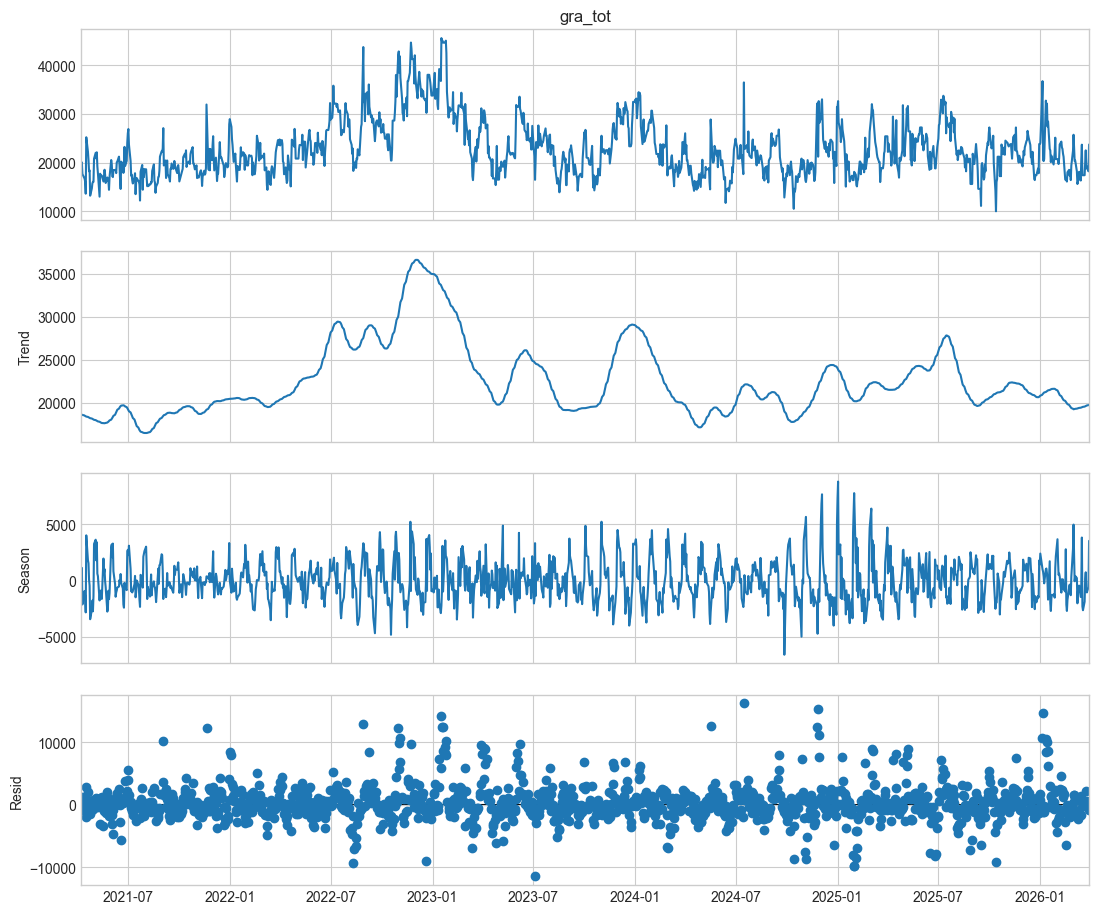

In [137]:


# 1. Clean and Set Index
df_fast['liq_last_upd_date'] = pd.to_datetime(df_fast['liq_last_upd_date'])
# Ensure we only have one value per day (the 1600/4PM snapshot)
df_clean = df_fast.drop_duplicates(subset='liq_last_upd_date', keep='last')
df_clean = df_clean.set_index('liq_last_upd_date').sort_index()


# 3. Handle Gaps (Critical for STL)
# We reindex to Business Days and forward-fill the liquidity from the previous day
df_resampled = df_clean['gra_tot'].asfreq('B').ffill()

# 4. Run STL
# period=21 assumes a business-month seasonality (21 trading days)
# robust=True handles outliers (like massive lumpy tax payments)
stl = STL(df_resampled, period=21, robust=True)
res = stl.fit()

# 5. Plot the Decomposition
fig = res.plot()
fig.set_size_inches(12, 10)
plt.show()


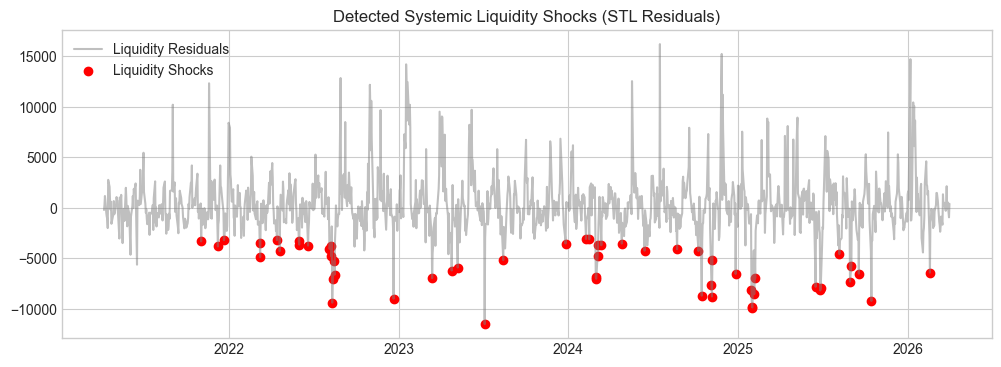

In [138]:
# 1. Extract the Residuals from your STL result
resid = res.resid

rolling_mu = resid.rolling(window=100).mean()
rolling_sigma = resid.rolling(window=100).std()

# 3. Generate the Stress Flag
# A 'Negative Spike' is when liquidity is > 2 standard deviations 
# BELOW the expected seasonal trend.
stress_threshold = rolling_mu - (1.5 * rolling_sigma)
stress_flag = (resid < stress_threshold).astype(int)

stress_signal = stress_flag.rolling(window=5, min_periods=1).max()

# 5. Visualize the 'Attacks'
plt.figure(figsize=(12, 4))
plt.plot(resid, label='Liquidity Residuals', color='gray', alpha=0.5)
plt.scatter(stress_flag[stress_flag==1].index, 
            resid[stress_flag==1], color='red', label='Liquidity Shocks')
plt.title("Detected Systemic Liquidity Shocks (STL Residuals)")
plt.legend()
plt.show()


NameError: name 'df_macro_clean' is not defined

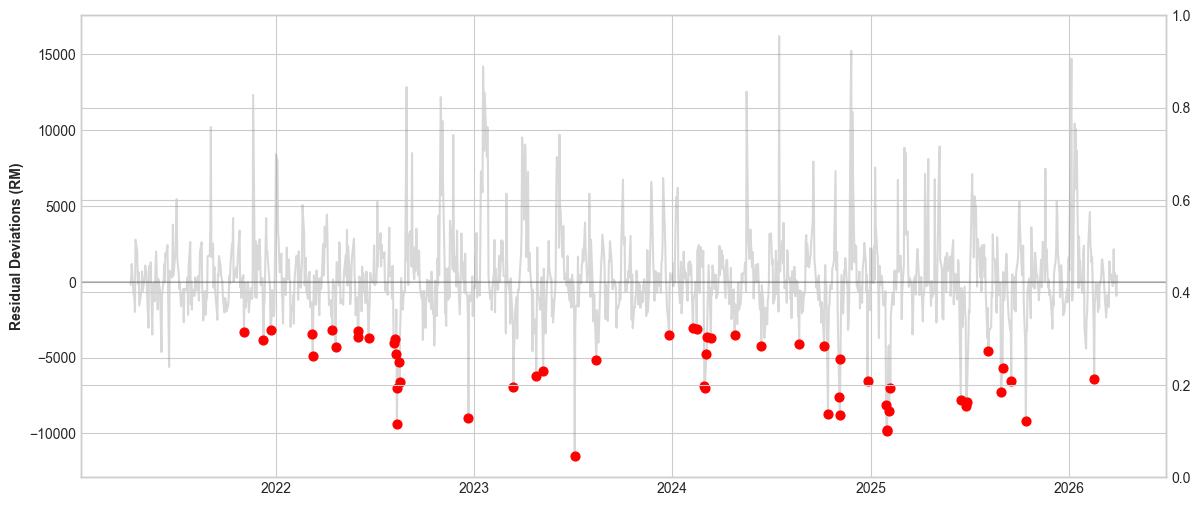

In [139]:
import matplotlib.pyplot as plt

# 1. Setup the plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- PRIMARY AXIS: Liquidity Residuals & Shocks ---
ax1.plot(resid, label='Liquidity Residuals (RM Billions)', color='gray', alpha=0.3)
ax1.scatter(stress_flag[stress_flag==1].index, 
            resid[stress_flag==1], 
            color='red', s=40, label='Liquidity Shocks (<-2σ)', zorder=5)

ax1.set_ylabel('Residual Deviations (RM)', fontweight='bold')
ax1.axhline(0, color='black', alpha=0.2)

# --- SECONDARY AXIS: OPR Step Function ---
ax2 = ax1.twinx()
color_opr = 'tab:orange'
ax2.step(df_macro_clean.index, df_macro_clean['opr'], 
         color=color_opr, linewidth=2.5, where='post', label='OPR (%)')
ax2.set_ylabel('OPR Level (%)', color=color_opr, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_opr)

# --- VISUAL CUES ---
plt.title("Systemic Stress vs. Policy Response: Red Dots as OPR Lead Indicators", fontsize=14)
ax1.grid(True, alpha=0.2)

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:

# 1. Setup Base URL and Years
base_url = "https://api.bnm.gov.my/public/opr" # Fixed the 'null' and 'bih' path
years = [2021, 2022, 2023, 2024, 2025, 2026]
all_opr = []


for year in years:
    # Standard BNM path is /opr/year/{year}
    url = f"{base_url}/year/{year}"
    r = requests.get(url, headers=headers)
    
    if r.status_code == 200:
        data = r.json().get('data', [])
        all_opr.extend(data)
    else:
        print(f"Failed to fetch OPR for {year}: Status {r.status_code}")
    

# 2. Convert and Clean
df_opr = pd.DataFrame(all_opr)

# BNM returns 'effective_date' and 'change_in_bps'
if not df_opr.empty:
    df_opr['date'] = pd.to_datetime(df_opr['date'])
    df_opr = df_opr.sort_values('date')
    
    # Save for your backtest
    df_opr.to_csv("bnm_opr_history.csv", index=False)

print(f"Successfully pulled {len(df_opr)} OPR change events.")
df_opr.tail()


Successfully pulled 34 OPR change events.


,year,date,change_in_opr,new_opr_level
28,2025,2025-07-09,-0.25,2.75
27,2025,2025-09-04,0.00,2.75
26,2025,2025-11-06,0.00,2.75
33,2026,2026-01-22,0.00,2.75
32,2026,2026-03-05,0.00,2.75


In [ ]:
df_working = df_fast.merge(df_opr, left_on = "liq_last_upd_date", right_on = "date", how = "outer")

# 1. Create a consolidated date column to ensure a perfect timeline
# This handles cases where OPR changed on a day with no liquidity reporting
df_working['final_date'] = df_working['liq_last_upd_date'].fillna(df_working['date'])

# 2. SORT IS CRITICAL - ffill() only works forward in time
df_working = df_working.sort_values('final_date')

# 3. Forward Fill the OPR columns 
# (This carries the 'Current OPR' into every liquidity reporting day)
opr_cols = [col for col in df_opr.columns if col != 'date']
df_working[opr_cols] = df_working[opr_cols].ffill()

# 4. Now drop the 'Ghost' rows 
# These are the OPR change dates that don't have liquidity data
df_working = df_working.dropna(subset="liq_id")

# 5. Clean up the extra date columns
df_working = df_working.drop(columns=['date', 'final_date'])

df_working.head()


,liq_id,liq_last_upd_date,liq_last_upd_time,liq_desc,prin,agr_opn_bal,bnm_mm_repo_mat,bnm_mm_repo_ten,oth_bnm_mkt_non_act,gov_opr,bnm_gov_sec_red,cpn_div_pay,sta_rsv,net_pay_con_isl,gra_tot,liq_rem,year,change_in_opr,new_opr_level
2,2.021000e+11,2021-04-07,09:32:56,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.2,38114.2,0.0,828.2,0.0,0.0,297.6,869.2,73.8,40746.2,"OPERATIONS:\r\nAt 1600 hrs, BNM will conduct u...",2021.0,0.0,1.75
3,2.021000e+11,2021-04-07,09:32:56,Liquidity Position as at 07 Apr 2021 (RM mil),Islamic,118.1,21824.9,0.0,0.0,-174.7,0.0,204.2,881.5,-73.8,22780.2,"OPERATIONS:\r\nAt 1600 hrs, BNM will conduct u...",2021.0,0.0,1.75
4,2.021000e+11,2021-04-07,10:39:55,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.2,38114.2,-4620.0,626.4,-251.1,0.0,297.6,523.8,338.5,35592.6,NaN,2021.0,0.0,1.75
5,2.021000e+11,2021-04-07,10:39:55,Liquidity Position as at 07 Apr 2021 (RM mil),Islamic,118.1,21824.9,-3050.0,-17.7,-256.8,0.0,204.2,30.2,-338.5,18514.4,NaN,2021.0,0.0,1.75
6,2.021000e+11,2021-04-07,15:30:11,Liquidity Position as at 07 Apr 2021 (RM mil),Conventional,563.2,38114.2,-4820.0,654.2,-260.3,0.0,297.6,922.8,250.9,35722.6,NaN,2021.0,0.0,1.75


In [ ]:
# 1. Force the collapse to Daily (16:00 Final Position only)
df_daily = df_working.copy()
df_daily['liq_last_upd_date'] = pd.to_datetime(df_daily['liq_last_upd_date'])

# Only keep the final settled position of the day
df_daily = df_daily.sort_values(['liq_last_upd_date', 'liq_last_upd_time'])
df_daily = df_daily.drop_duplicates(subset='liq_last_upd_date', keep='last')

# 2. Re-run the STL on this clean daily series
# (You need a fresh STL because the old 'res' had 9k rows)
df_daily = df_daily.set_index('liq_last_upd_date').asfreq('B').ffill()
res_daily = STL(df_daily['gra_tot'], period=21).fit()

# 3. Re-run Granger on the CLEAN data
df_macro_clean = pd.DataFrame({
    'opr': df_daily['new_opr_level'],
    'liq_trend': res_daily.trend,
    'liq_resid': res_daily.resid
}).dropna()
df_diff = df_macro_clean.diff().dropna()
df_diff["opr"] = df_macro_clean["opr"]
print(f"Clean Daily Observations: {len(df_macro_clean)}")
# Now maxlag=66 actually means ~3 months
gc_opr_clean = grangercausalitytests(df_diff[['opr', 'liq_trend']], maxlag=66)


Clean Daily Observations: 1300

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0570  , p=0.3041  , df_denom=1295, df_num=1
ssr based chi2 test:   chi2=1.0595  , p=0.3033  , df=1
likelihood ratio test: chi2=1.0591  , p=0.3034  , df=1
parameter F test:         F=1.0570  , p=0.3041  , df_denom=1295, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.0355  , p=0.1310  , df_denom=1292, df_num=2
ssr based chi2 test:   chi2=4.0867  , p=0.1296  , df=2
likelihood ratio test: chi2=4.0803  , p=0.1300  , df=2
parameter F test:         F=2.0355  , p=0.1310  , df_denom=1292, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3881  , p=0.2448  , df_denom=1289, df_num=3
ssr based chi2 test:   chi2=4.1868  , p=0.2420  , df=3
likelihood ratio test: chi2=4.1801  , p=0.2427  , df=3
parameter F test:         F=1.3881  , p=0.2448  , df_denom=1289, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F

In [ ]:
# Create a volatility proxy (Absolute Residuals)
df_macro_clean['liq_vol'] = df_macro_clean['liq_resid'].abs()

# Test if Volatility leads OPR
gc_vol = grangercausalitytests(df_macro_clean[['opr', 'liq_vol']], maxlag=66)



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.8385  , p=0.0503  , df_denom=1296, df_num=1
ssr based chi2 test:   chi2=3.8474  , p=0.0498  , df=1
likelihood ratio test: chi2=3.8417  , p=0.0500  , df=1
parameter F test:         F=3.8385  , p=0.0503  , df_denom=1296, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.7174  , p=0.0664  , df_denom=1293, df_num=2
ssr based chi2 test:   chi2=5.4557  , p=0.0654  , df=2
likelihood ratio test: chi2=5.4443  , p=0.0657  , df=2
parameter F test:         F=2.7174  , p=0.0664  , df_denom=1293, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.8599  , p=0.1345  , df_denom=1290, df_num=3
ssr based chi2 test:   chi2=5.6099  , p=0.1322  , df=3
likelihood ratio test: chi2=5.5978  , p=0.1329  , df=3
parameter F test:         F=1.8599  , p=0.1345  , df_denom=1290, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.6417  , p=0.

Granger causality indicates 2 month lead time from BNM liquidity shocks to OPR

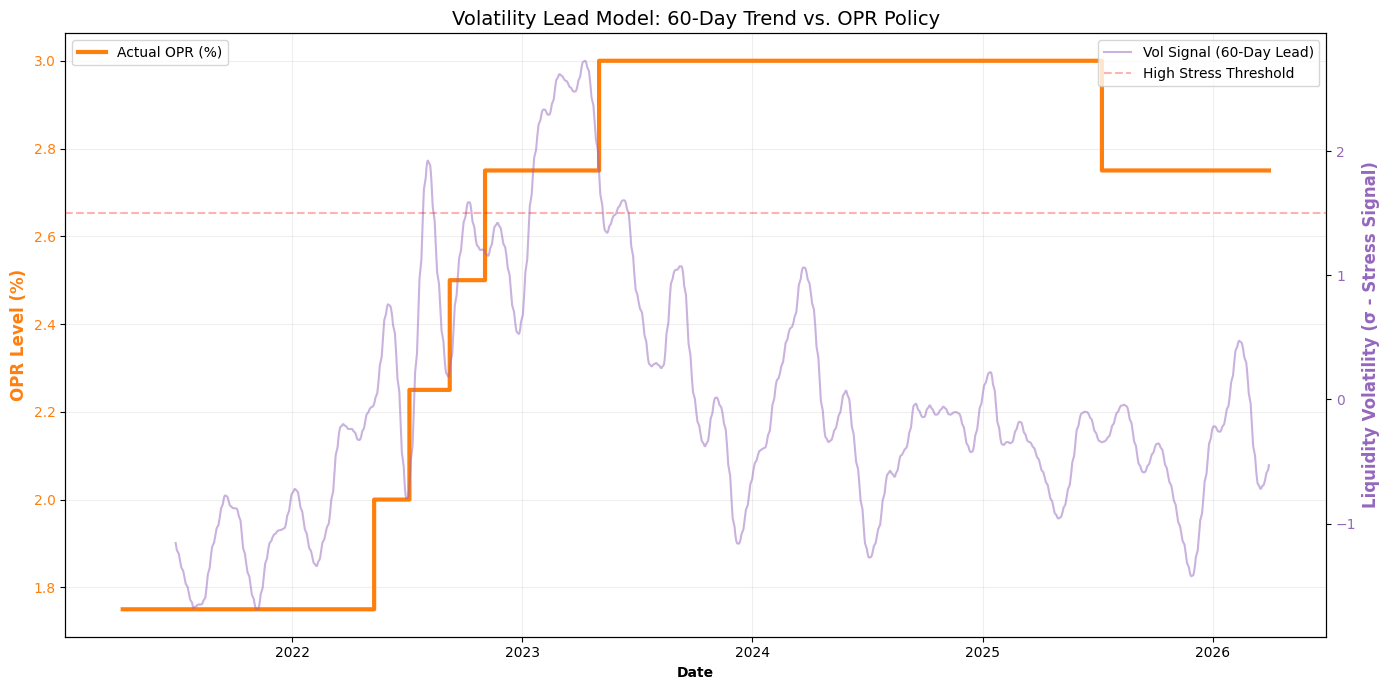

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the 'Stress Signal' (21-day Rolling Volatility of Residuals)
# We use Absolute Residuals smoothed over a month to find 'Clusters' of stress
df_macro_clean['liq_vol_signal'] = df_macro_clean['liq_trend']

# 2. Shift the Volatility Signal forward by the 'Golden Lag' (40 Days)
# This aligns the 'Cause' (Volatility) with the 'Effect' (OPR Change)
vol_lead = 60
df_plot = df_macro_clean.copy()
df_plot['vol_shifted'] = df_plot['liq_vol_signal'].shift(vol_lead)

# 3. Standardize the Volatility for the Y-Axis (Z-score)
df_plot['vol_z'] = (df_plot['vol_shifted'] - df_plot['vol_shifted'].mean()) / df_plot['vol_shifted'].std()

# 4. Dual-Axis Plotting
fig, ax1 = plt.subplots(figsize=(14, 7))

# Axis 1: Raw OPR Level (%)
color_opr = 'tab:orange'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('OPR Level (%)', color=color_opr, fontsize=12, fontweight='bold')
ax1.step(df_plot.index, df_plot['opr'], color=color_opr, linewidth=3, label='Actual OPR (%)', where='post')
ax1.tick_params(axis='y', labelcolor=color_opr)

# Axis 2: Liquidity Volatility (Standardized)
ax2 = ax1.twinx()
color_vol = 'tab:purple' # Purple for Volatility/Stress
ax2.set_ylabel('Liquidity Volatility (σ - Stress Signal)', color=color_vol, fontsize=12, fontweight='bold')
ax2.plot(df_plot.index, df_plot['vol_z'], color=color_vol, alpha=0.5, label=f'Vol Signal ({vol_lead}-Day Lead)')
ax2.tick_params(axis='y', labelcolor=color_vol)

# Add a 'Danger Threshold' line at +1.5 Sigma
ax2.axhline(1.5, color='red', linestyle='--', alpha=0.3, label='High Stress Threshold')

plt.title(f"Volatility Lead Model: {vol_lead}-Day Trend vs. OPR Policy", fontsize=14)
fig.tight_layout()
ax1.grid(True, alpha=0.2)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()


In [ ]:
import os
import requests
import numpy as np
from dotenv import load_dotenv

# 1. Load the environment variables from the .env file
load_dotenv()


True

In [ ]:
import os
import requests
import numpy as np
from dotenv import load_dotenv

load_dotenv()

def get_hotel_price(city, check_in, check_out):
    """Basic fetcher (reused from your code)"""
    params = {
        "engine": "google_hotels",
        "q": city,
        "check_in_date": check_in,
        "check_out_date": check_out,
        "api_key": os.getenv("SERP_KEY")
    }
    res = requests.get("https://serpapi.com/search", params=params).json()
    prices = [float(h['rate_per_night']['extracted_lowest']) 
              for h in res.get('properties', []) if h.get('rate_per_night', {}).get('extracted_lowest')]
    return np.mean(prices) if prices else 0

# --- THE SEASONAL ADJUSTMENT LOGIC ---

# 1. Target Date (e.g., April 10 - Good Friday)
target_price = get_hotel_price("Kuala Lumpur", "2026-04-10", "2026-04-11")

# 2. Control Group (Average of 3 other nearby "Normal" weekends)
# This creates a 'Synthetic Baseline' for April
baselines = [
    get_hotel_price("Kuala Lumpur", "2026-04-17", "2026-04-18"),
    get_hotel_price("Kuala Lumpur", "2026-04-24", "2026-04-25"),
    get_hotel_price("Kuala Lumpur", "2026-05-15", "2026-05-16")
]
seasonal_baseline = np.mean([b for b in baselines if b > 0])

# 3. The "True" Momentum Signal
# We subtract 1 to see the % premium over the 'normal' seasonal expectation
true_momentum = (target_price / seasonal_baseline) - 1

print(f"Target Weekend Price: RM {target_price:.2f}")
print(f"Seasonal Baseline:    RM {seasonal_baseline:.2f}")
print(f"Seasonally Adjusted Signal: {true_momentum:.2%}")


Target Weekend Price: RM 141.55
Seasonal Baseline:    RM 148.97
Seasonally Adjusted Signal: -4.98%


In [ ]:
import os
import requests
import numpy as np
from datetime import datetime, timedelta
from dotenv import load_dotenv

load_dotenv()

def get_detailed_hotel_data(city, check_in):
    api_key = os.getenv("SERP_KEY")
    check_in_dt = datetime.strptime(check_in, "%Y-%m-%d")
    check_out = (check_in_dt + timedelta(days=1)).strftime("%Y-%m-%d")
    
    params = {
        "engine": "google_hotels",
        "q": city,
        "check_in_date": check_in,
        "check_out_date": check_out,
        "api_key": api_key,
        "currency": "MYR",
        "gl": "my"
    }
    
    try:
        response = requests.get("https://serpapi.com/search", params=params).json()
        properties = response.get("properties", [])
        
        # Create a dictionary of {Hotel Name: Price} for matching
        hotel_map = {}
        for h in properties:
            name = h.get("name")
            price = h.get("rate_per_night", {}).get("extracted_lowest")
            if name and price:
                hotel_map[name] = float(price)
        
        return {
            "map": hotel_map,
            "total_found": response.get("search_information", {}).get("total_results", 0),
            "date": check_in
        }
    except Exception as e:
        print(f"❌ Error fetching {check_in}: {e}")
        return None

# --- EXECUTION LOGIC ---

location = "Kuala Lumpur"
target = get_detailed_hotel_data(location, "2026-04-03")
baseline = get_detailed_hotel_data(location, "2026-06-15")

if target and baseline:
    t_map = target['map']
    b_map = baseline['map']
    
    # 1. FIND MATCHED PAIRS (Hotels available on BOTH dates)
    common_hotels = set(t_map.keys()).intersection(set(b_map.keys()))
    
    matched_momentums = []
    for name in common_hotels:
        change = (t_map[name] / b_map[name]) - 1
        matched_momentums.append(change)
    
    # 2. CALCULATE TRUE SCARCITY (Hotels available in June but SOLD OUT in April)
    # This is the most "honest" volume signal
    baseline_hotels = set(b_map.keys())
    sold_out_in_target = baseline_hotels - set(t_map.keys())
    true_scarcity = len(sold_out_in_target) / len(baseline_hotels) if baseline_hotels else 0

    # 3. STATISTICAL OUTPUT
    print(f"\n--- MATCHED-PAIR TOURISM SIGNAL: {location.upper()} ---")
    print(f"Hotels in Sample: {len(common_hotels)}")
    
    if common_hotels:
        avg_matched_momentum = np.mean(matched_momentums)
        print(f"Matched-Pair Momentum: {avg_matched_momentum:+.2%} (Same-store sales proxy)")
    else:
        print("Matched-Pair Momentum: N/A (Zero overlap in available hotels)")

    print(f"True Scarcity Index:   {true_scarcity:.2%} (June hotels missing in April)")
    
    # 4. FLOOR PRICE (Cheapest of all available)
    t_floor = min(t_map.values()) if t_map else 0
    b_floor = min(b_map.values()) if b_map else 0
    floor_rise = (t_floor / b_floor) - 1 if b_floor > 0 else 0
    print(f"Market Floor Rise:     {floor_rise:+.2%}")

else:
    print("❌ Critical Error: Data fetch failed.")



--- MATCHED-PAIR TOURISM SIGNAL: KUALA LUMPUR ---
Hotels in Sample: 9
Matched-Pair Momentum: +21.43% (Same-store sales proxy)
True Scarcity Index:   55.00% (June hotels missing in April)
Market Floor Rise:     +11.48%


In [ ]:
import os
import requests
import numpy as np
from datetime import datetime, timedelta
from dotenv import load_dotenv

load_dotenv()

def fetch_serp_data(params):
    """Universal stable fetcher for SerpApi."""
    params["api_key"] = os.getenv("SERP_KEY")
    try:
        response = requests.get("https://serpapi.com/search", params=params)
        return response.json()
    except Exception as e:
        print(f"❌ API Request failed: {e}")
        return {}

def get_demand_signal(location):
    """Google Trends via SerpApi (Replaces pytrends)."""
    params = {
        "engine": "google_trends",
        "q": f"Hotels in {location}",
        "geo": "MY",
        "date": "today 3-m",
        "cat": "67" # Travel Category
    }
    data = fetch_serp_data(params)
    timeline = data.get("interest_over_time", {}).get("timeline_data", [])
    
    if not timeline:
        return 0.0
    
    # Compare last week to 3-month average
    values = [int(i.get("values", [0])[0].get("extracted_value", 0)) for i in timeline]
    
    if not values:
        return 0.0
    
    avg_total = np.mean(values)
    
    # If the denominator is 0, we return 0.0 to avoid the 'nan' spread
    if avg_total == 0:
        return 0.0
        
    return (np.mean(values[-7:]) / avg_total) - 1
    return (np.mean(values[-7:]) / np.mean(values)) - 1 if values else 0

def get_hotel_metrics(city, check_in):
    """Supply/Pricing Proxy via SerpApi."""
    check_in_dt = datetime.strptime(check_in, "%Y-%m-%d")
    check_out = (check_in_dt + timedelta(days=1)).strftime("%Y-%m-%d")
    
    params = {
        "engine": "google_hotels",
        "q": city,
        "check_in_date": check_in,
        "check_out_date": check_out,
        "currency": "MYR",
        "gl": "my"
    }
    
    data = fetch_serp_data(params)
    properties = data.get("properties", [])
    
    # Create a map of {Hotel Name: Price}
    hotel_map = {h['name']: float(h['rate_per_night']['extracted_lowest']) 
                 for h in properties if h.get('rate_per_night', {}).get('extracted_lowest')}
    
    return {"map": hotel_map, "date": check_in}

# --- EXECUTION ENGINE ---

location = "Genting Highlands, Pahang"
demand_momentum = get_demand_signal(location)
target = get_hotel_metrics(location, "2026-04-10") # Concert/Event weekend
baseline = get_hotel_metrics(location, "2026-06-15") # Normal baseline

if target['map'] and baseline['map']:
    # 1. Matched-Pair Momentum (Same-Store Revenue Signal)
    common = set(target['map'].keys()) & set(baseline['map'].keys())
    price_momentum = np.mean([target['map'][n]/baseline['map'][n] - 1 for n in common]) if common else 0
    
    # 2. Market Floor Rise (Physical Scarcity Signal)
    floor_rise = (min(target['map'].values()) / min(baseline['map'].values())) - 1
    
    # 3. Final Conviction Score
    alpha_score = (demand_momentum * 0.3) + (price_momentum * 0.4) + (floor_rise * 0.3)

    print(f"\n--- 🚀 TOURISM ALPHA: {location.upper()} ---")
    print(f"Demand Momentum (Search): {demand_momentum:+.2%}")
    print(f"Price Momentum (Supply):  {price_momentum:+.2%}")
    print(f"Market Floor Rise:        {floor_rise:+.2%}")
    print(f"--------------------------------------------------")
    print(f"CONVICTION SCORE: {alpha_score:.4f}")
else:
    print("❌ Critical Error: Data fetch returned empty maps.")



--- 🚀 TOURISM ALPHA: GENTING HIGHLANDS, PAHANG ---
Demand Momentum (Search): +0.00%
Price Momentum (Supply):  +12.83%
Market Floor Rise:        +11.25%
--------------------------------------------------
CONVICTION SCORE: 0.0851


In [ ]:
def get_hotel_signals(city, target_date="2026-04-10", baseline_date="2026-06-15"):
    """
    Encapsulates the supply-side logic: Matched-Pair Momentum & Floor Rise.
    Returns: (price_momentum, floor_rise)
    """
    # Use the detailed fetcher we built earlier
    target_data = get_detailed_hotel_data(city, target_date)
    baseline_data = get_detailed_hotel_data(city, baseline_date)
    
    if not target_data or not baseline_data:
        return 0.0, 0.0
    
    t_map = target_data['map']
    b_map = baseline_data['map']
    
    # 1. Matched-Pair Momentum (The 'Same-Store' Revenue Signal)
    common_hotels = set(t_map.keys()) & set(b_map.keys())
    if common_hotels:
        price_mom = np.mean([t_map[name] / b_map[name] - 1 for name in common_hotels])
    else:
        price_mom = 0.0
        
    # 2. Market Floor Rise (The Scarcity/Volume Signal)
    # We use the minimum price found in the entire set for that date
    t_floor = min(t_map.values()) if t_map else 0
    b_floor = min(b_map.values()) if b_map else 0
    
    floor_rise = (t_floor / b_floor) - 1 if b_floor > 0 else 0
    
    return price_mom, floor_rise


In [ ]:
def get_structural_hotel_signals(city, target_month="2026-05", baseline_month="2026-09"):
    """
    Calculates structural pricing power by averaging multiple weekend snapshots
    to eliminate 'Event Noise'.
    """
    # 1. Generate 4 sample weekends for each period (Structural Sampling)
    def get_weekends(year_month):
        # Simplistic: targets the first 4 Fridays of the month
        return [f"{year_month}-{1 + (i*7):02d}" for i in range(4)]

    target_dates = get_weekends(target_month)
    baseline_dates = get_weekends(baseline_month)
    
    all_target_maps = []
    all_baseline_maps = []

    # 2. Multi-point Sampling
    for t_date, b_date in zip(target_dates, baseline_dates):
        t_data = get_detailed_hotel_data(city, t_date)
        b_data = get_detailed_hotel_data(city, b_date)
        if t_data: all_target_maps.append(t_data['map'])
        if b_data: all_baseline_maps.append(b_data['map'])

    if not all_target_maps or not all_baseline_maps:
        return 0.0, 0.0

    # 3. Aggregate into a "Structural Price Map" (Median price per hotel over 4 weeks)
    def aggregate_maps(maps):
        aggregated = {}
        all_keys = set().union(*(m.keys() for m in maps))
        for hotel in all_keys:
            prices = [m[hotel] for m in maps if hotel in m]
            if len(prices) >= 2: # Require at least 2 data points for structural validity
                aggregated[hotel] = np.median(prices) # Median is more robust than mean
        return aggregated

    struct_target = aggregate_maps(all_target_maps)
    struct_baseline = aggregate_maps(all_baseline_maps)

    # 4. Calculate Structural Momentum (Same-Store Median)
    common_hotels = set(struct_target.keys()) & set(struct_baseline.keys())
    if common_hotels:
        struct_p_mom = np.mean([struct_target[n] / struct_baseline[n] - 1 for n in common_hotels])
    else:
        struct_p_mom = 0.0

    # 5. Structural Floor Rise
    # Comparing the 'normal' cheap price of Period A vs Period B
    t_floor = np.median(list(struct_target.values())) if struct_target else 0
    b_floor = np.median(list(struct_baseline.values())) if struct_baseline else 0
    struct_f_rise = (t_floor / b_floor) - 1 if b_floor > 0 else 0

    return struct_p_mom, struct_f_rise


# REQUIRES FORWARD TESTING

In [ ]:
# --- REFINED MTCI LOOP ---
city_weights = {
    "Kuala Lumpur": 0.40,
    "Genting Highlands, Pahang": 0.20,
    "Langkawi": 0.25,
    "Johor Bahru": 0.15
}

results = []
print(f"{'CITY':<25} | {'DEMAND':<10} | {'PRICE':<10} | {'FLOOR':<10} | {'RHS'}")
print("-" * 75)

for city, weight in city_weights.items():
    # 1. Fetch RHS data
    d_mom = get_demand_signal(city)
    p_mom, f_rise = get_structural_hotel_signals(city)
    
    # 2. Calculate Regional Health Score (RHS)
    # Using your standardized weights: 0.3 Demand, 0.4 Price, 0.3 Floor
    rhs = (0.3 * d_mom) + (0.4 * p_mom) + (0.3 * f_rise)
    
    # Handle the NaN case: If any value is NaN, we treat RHS as 0 (Neutral)
    if np.isnan(rhs): rhs = 0.0
    
    results.append(rhs * weight)
    
    # 3. Print the breakdown for the Dashboard
    print(f"{city:<25} | {d_mom:>9.2%} | {p_mom:>9.2%} | {f_rise:>9.2%} | {rhs:.4f}")

# 4. Final Composite
malaysia_tourism_index = sum(results)
print("-" * 75)
print(f"🚀 MALAYSIA TOURISM COMPOSITE INDEX (MTCI): {malaysia_tourism_index:.4f}")


CITY                      | DEMAND     | PRICE      | FLOOR      | RHS
---------------------------------------------------------------------------


NameError: name 'get_demand_signal' is not defined

In [ ]:
import pandas as pd
import requests
import io

def load_parquet(url):
    response = requests.get(url)
    if response.status_code == 200:
        return pd.read_parquet(io.BytesIO(response.content))
    return None

# Load FDI - Filter for China/Hong Kong
df_fdi = load_parquet("https://storage.dosm.gov.my/bop/fdi_flows.parquet")
print(df_fdi.head())
# Try a broader search to catch the country-level tables

# Load Trade - Look for "Intermediate Goods"
df_trade = load_parquet("https://storage.dosm.gov.my/trade/trade_sitc_1d.parquet")
# Group monthly trade data to quarterly to match FDI
df_trade['date'] = pd.to_datetime(df_trade['date'])
df_trade_qtr = df_trade.resample('QE', on='date').sum()
print(df_trade_qtr.head())

# Load GFCF - To check for Crowding Out
df_gfcf = load_parquet("https://storage.dosm.gov.my/gdp/gdp_gfcf.parquet")
print(df_gfcf)


         date     inflow    outflow        net
0  2008-01-01  20.498320  16.831633   3.666686
1  2008-04-01  30.097369  14.332162  15.765207
2  2008-07-01  17.919999  17.617626   0.302373
3  2008-10-01  20.750972  16.560738   4.190235
4  2009-01-01  17.201307  14.546589   2.654718
                                                      section       exports  \
date                                                                          
2000-03-31  overall0123456789overall0123456789overall01234...  1.694064e+11   
2000-06-30  overall0123456789overall0123456789overall01234...  1.818696e+11   
2000-09-30  overall0123456789overall0123456789overall01234...  2.033073e+11   
2000-12-31  overall0123456789overall0123456789overall01234...  1.919574e+11   
2001-03-31  overall0123456789overall0123456789overall01234...  1.721503e+11   

                 imports  
date                      
2000-03-31  1.357511e+11  
2000-06-30  1.570498e+11  
2000-09-30  1.729790e+11  
2000-12-31  1.571379e+11  
20

# Ekonomi Madani
- Monthly CPI by Division (OpenDOSM)
- Wholesale and Retail Trade (OpenDOSM)

In [ ]:
import numpy as np

class PolicySentinel:
    def __init__(self, target, actual):
        self.gap = target - actual
        
    def forecast_move(self, kpi_name):
        # A negative gap means we are underperforming
        if kpi_name == "Labor Share" and self.gap > 2.0:
            return "🚀 HIGH PROBABILITY: Minimum Wage Hike / Mandatory PWS Rollout"
            
        if kpi_name == "Fiscal Deficit" and self.gap < -0.2:
            return "⚠️ CRITICAL: Expect GST reintroduction or Subsidy Rationalization"
            
        if kpi_name == "Tourism Revenue" and self.gap > 50:
            return "🎟️ LIKELY: Further Visa Liberalization (China/India) or MYR promo"
            
        return "✅ REGIME: Policy Stability"

# Example Usage for 2026
labor_gap = PolicySentinel(target=38.5, actual=33.1)
print(f"Policy Forecast: {labor_gap.forecast_move('Labor Share')}")


Policy Forecast: 🚀 HIGH PROBABILITY: Minimum Wage Hike / Mandatory PWS Rollout


In [ ]:
import requests
import pandas as pd
import time

# Years to pull (Current year is 2026)
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
headers = {"Accept": "application/vnd.BNM.API.v1+json"}
all_records = []

for year in years:
    url = f"https://api.bnm.gov.my/public/msb/1.30/year/{year}"
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            # The 'year' endpoint returns a list of monthly dicts
            year_data = response.json().get('data', [])
            all_records.extend(year_data)
            print(f"✅ Fetched {year}: {len(year_data)} months found.")
        else:
            print(f"❌ Error {year}: {response.status_code}")
    except Exception as e:
        print(f"⚠️ Failed {year}: {e}")
    
    # Pause to respect BNM rate limits
    time.sleep(0.5)


✅ Fetched 2019: 13 months found.
✅ Fetched 2020: 13 months found.
✅ Fetched 2021: 13 months found.
✅ Fetched 2022: 13 months found.
✅ Fetched 2023: 13 months found.
✅ Fetched 2024: 13 months found.
✅ Fetched 2025: 13 months found.
✅ Fetched 2026: 2 months found.


In [ ]:
import pandas as pd

# 1. Create DataFrame from the list of dictionaries
df_raw = pd.DataFrame(all_records)

# 2. Rename columns using the Literal Mapping
madani_mapping = {
    'year_dt': 'Year',
    'month_dt': 'Month',
    'tdp_no_card_trans': 'Total_Number_of_Card_Transactions_Millions',
    'tdp_t_pur_msia_lcl_cardholder': 'Total_Value_of_Purchases_made_in_Malaysia_by_Local_Cardholders',
    'tdp_t_pur_msia_for_cardholder': 'Total_Value_of_Purchases_made_in_Malaysia_by_Foreign_Cardholders',
    'tdp_t_pur_abroad_lcl_cardholder': 'Total_Value_of_Purchases_made_Abroad_by_Local_Cardholders',
    'tdp_t_cash_adv_msia_lcl_cardholder': 'Total_Value_of_Cash_Advances_in_Malaysia_by_Local_Cardholders',
    'tdp_t_cash_adv_msia_for_cardholder': 'Total_Value_of_Cash_Advances_in_Malaysia_by_Foreign_Cardholders',
    'tdp_t_cash_adv_abroad_lcl_cardholder': 'Total_Value_of_Cash_Advances_Abroad_by_Local_Cardholders',
    'tep_no_cd_cir_prin_card': 'Number_of_Principal_Cards_in_Circulation_Millions',
    'tep_no_cd_cir_sup_card': 'Number_of_Supplementary_Cards_in_Circulation_Millions',
    'tep_amt_cdt_line_ext': 'Total_Amount_of_Credit_Limit_Extended',
    'tep_t_outstdg_curr_bal': 'Total_Outstanding_Current_Balance',
    'tep_t_outstdg_overdue_bal_more_three_mth': 'Total_Overdue_Balance_More_than_3_Months',
    'tep_t_outstdg_overdue_bal_three_to_six_mth': 'Total_Overdue_Balance_3_to_6_Months',
    'tep_t_outstdg_overdue_bal_more_six_mth': 'Total_Overdue_Balance_More_than_6_Months'
}
df_raw = df_raw.rename(columns=madani_mapping)

# 3. SPLIT THE DATA
# Annual totals have NaN in 'Month'
df_monthly = df_raw.dropna(subset=['Month']).copy()
df_annual = df_raw[df_raw['Month'].isna()].copy()

# 4. FIX MONTHLY TIME-SERIES
df_monthly['Year'] = df_monthly['Year'].astype(int)
df_monthly['Month'] = df_monthly['Month'].astype(int)
df_monthly['Date'] = pd.to_datetime(df_monthly[['Year', 'Month']].assign(day=1))
df_monthly = df_monthly.sort_values('Date').set_index('Date')

# 5. CLEAN UP ANNUAL DATAFRAME
df_annual = df_annual.drop(columns=['Month']).set_index('Year')

# 6. DYNAMICALLY FIX NUMERIC COLS
# This picks all columns except 'Year' and 'Month' to avoid KeyErrors
numeric_cols = [v for k, v in madani_mapping.items() if v not in ['Year', 'Month']]

# Convert to numeric (errors='coerce' handles any unexpected strings)
df_monthly[numeric_cols] = df_monthly[numeric_cols].apply(pd.to_numeric, errors='coerce')
df_annual[numeric_cols] = df_annual[numeric_cols].apply(pd.to_numeric, errors='coerce')

print("✅ Monthly Time-Series Fixed & Converted")
print(df_monthly[numeric_cols[:3]].tail(3)) # Show first 3 numeric cols
print("\n✅ Annual Totals Fixed & Converted")
print(df_annual[numeric_cols[:3]].tail(3))


✅ Monthly Time-Series Fixed & Converted
            Total_Number_of_Card_Transactions_Millions  \
Date                                                     
2025-11-01                                   88.749544   
2025-12-01                                   95.778213   
2026-01-01                                   93.819536   

            Total_Value_of_Purchases_made_in_Malaysia_by_Local_Cardholders  \
Date                                                                         
2025-11-01                                       16662.244552                
2025-12-01                                       18215.125513                
2026-01-01                                       17850.644394                

            Total_Value_of_Purchases_made_in_Malaysia_by_Foreign_Cardholders  
Date                                                                          
2025-11-01                                        2082.614128                 
2025-12-01                               

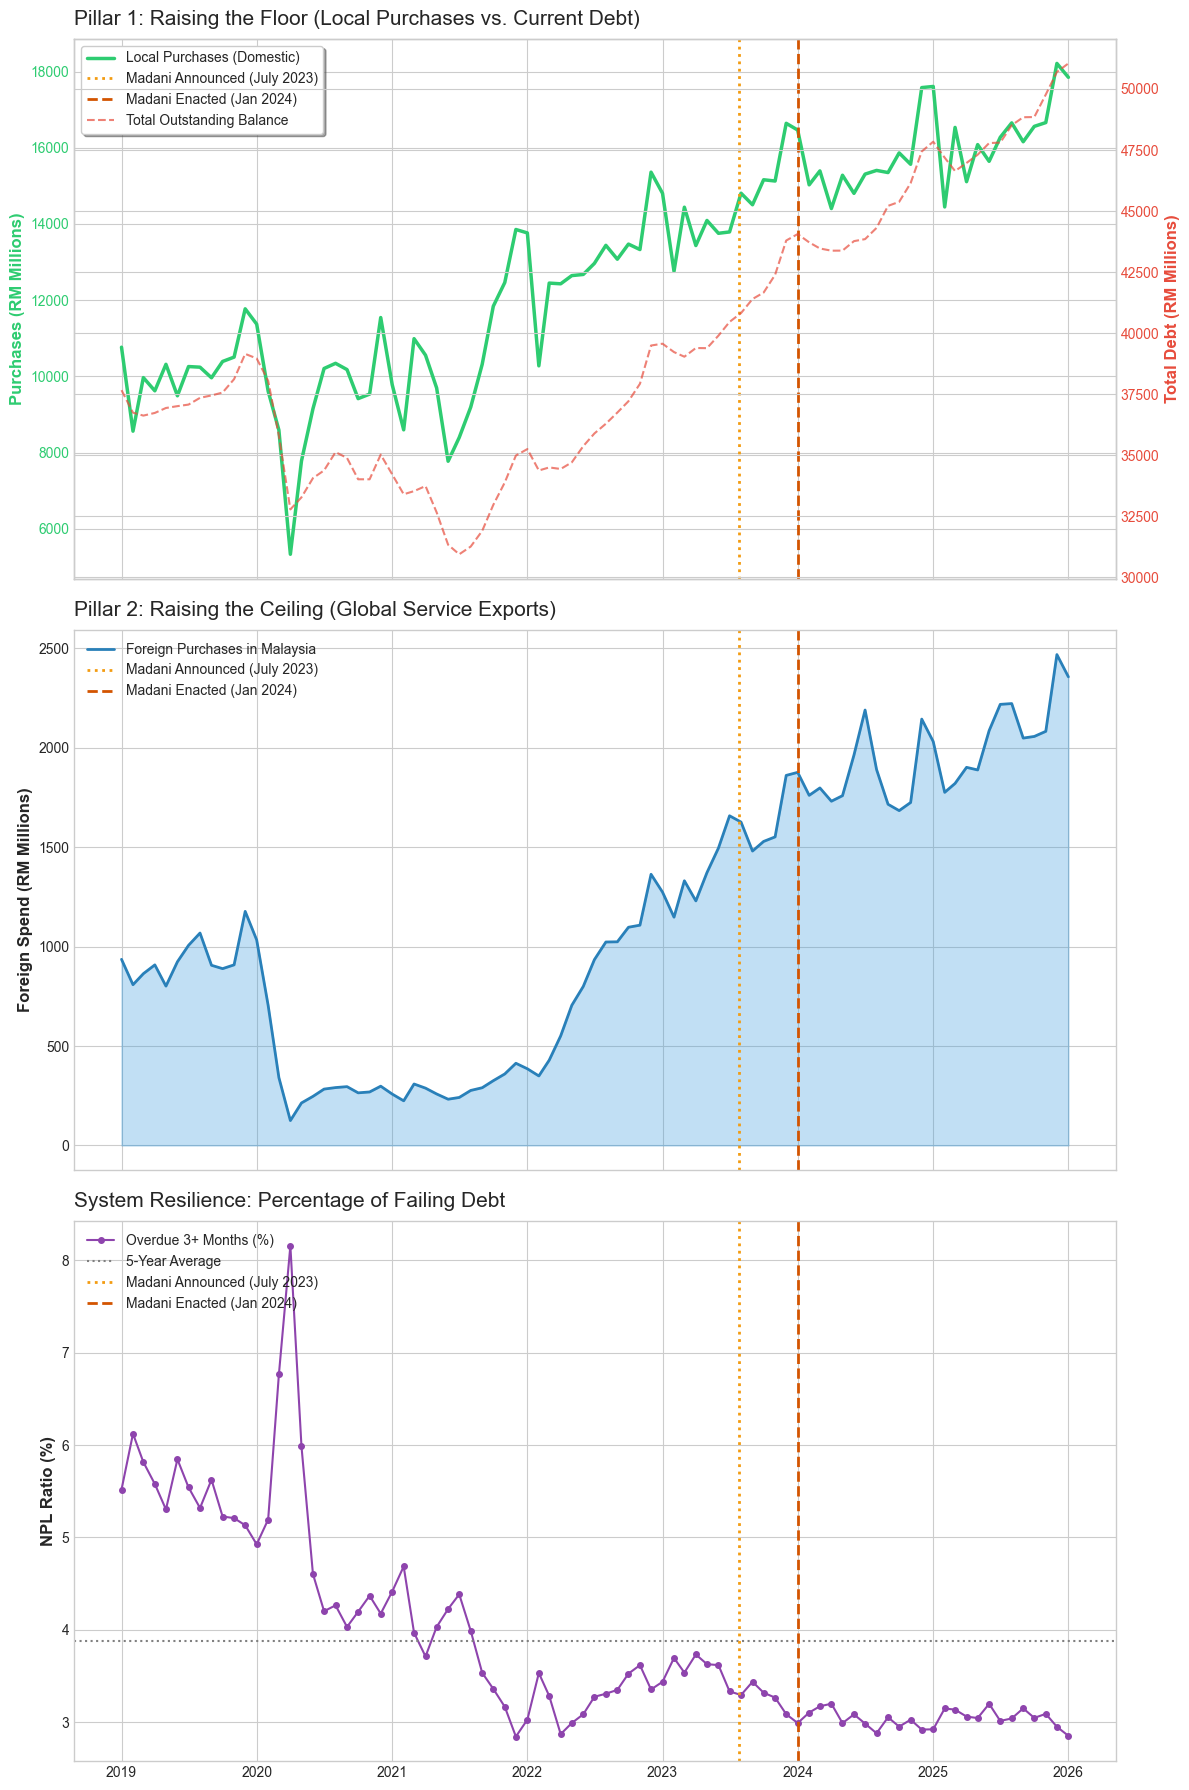

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the Madani Milestones
announcement_date = pd.to_datetime('2023-07-27')
enactment_date = pd.to_datetime('2024-01-01')

# Set style for a "Quant" look
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

# Helper function to add the lines and labels to each subplot
def add_madani_milestones(ax):
    # Announcement Line
    ax.axvline(announcement_date, color='#f39c12', linestyle=':', linewidth=2, label='Madani Announced (July 2023)')
    # Enactment Line
    ax.axvline(enactment_date, color='#d35400', linestyle='--', linewidth=2, label='Madani Enacted (Jan 2024)')

# --- PLOT 1: DOMESTIC CONSUMPTION VS. TOTAL DEBT ---
# Literal: Total_Value_of_Purchases_made_in_Malaysia_by_Local_Cardholders
ax1.plot(df_monthly.index, df_monthly['Total_Value_of_Purchases_made_in_Malaysia_by_Local_Cardholders'], 
         color='#2ecc71', label='Local Purchases (Domestic)', linewidth=2.5)
ax1.set_ylabel('Purchases (RM Millions)', color='#2ecc71', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2ecc71')

# Literal: Total_Outstanding_Current_Balance
ax1_debt = ax1.twinx()
ax1_debt.plot(df_monthly.index, df_monthly['Total_Outstanding_Current_Balance'], 
              color='#e74c3c', label='Total Outstanding Balance', linestyle='--', alpha=0.7)
ax1_debt.set_ylabel('Total Debt (RM Millions)', color='#e74c3c', fontsize=12, fontweight='bold')
ax1_debt.tick_params(axis='y', labelcolor='#e74c3c')

add_madani_milestones(ax1)
ax1.set_title('Pillar 1: Raising the Floor (Local Purchases vs. Current Debt)', fontsize=15, loc='left', pad=10)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_debt.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, shadow=True)

# --- PLOT 2: FOREIGN CAPITAL INFLOW ---
# Literal: Total_Value_of_Purchases_made_in_Malaysia_by_Foreign_Cardholders
ax2.fill_between(df_monthly.index, df_monthly['Total_Value_of_Purchases_made_in_Malaysia_by_Foreign_Cardholders'], 
                 color='#3498db', alpha=0.3)
ax2.plot(df_monthly.index, df_monthly['Total_Value_of_Purchases_made_in_Malaysia_by_Foreign_Cardholders'], 
         color='#2980b9', linewidth=2, label='Foreign Purchases in Malaysia')
add_madani_milestones(ax2)
ax2.set_ylabel('Foreign Spend (RM Millions)', fontsize=12, fontweight='bold')
ax2.set_title('Pillar 2: Raising the Ceiling (Global Service Exports)', fontsize=15, loc='left', pad=10)
ax2.legend(loc='upper left')

# --- PLOT 3: DEBT FAILURE RATE (NPL RATIO) ---
# Literal: Total_Overdue_Balance_More_than_3_Months / Total_Outstanding_Current_Balance
npl_ratio = (df_monthly['Total_Overdue_Balance_More_than_3_Months'] / df_monthly['Total_Outstanding_Current_Balance']) * 100
ax3.plot(df_monthly.index, npl_ratio, color='#8e44ad', marker='o', markersize=4, label='Overdue 3+ Months (%)')
ax3.axhline(npl_ratio.mean(), color='grey', linestyle=':', label='5-Year Average')
add_madani_milestones(ax3)
ax3.set_ylabel('NPL Ratio (%)', fontsize=12, fontweight='bold')
ax3.set_title('System Resilience: Percentage of Failing Debt', fontsize=15, loc='left', pad=10)
ax3.legend(loc='upper left')

# Formatting cleanup
plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
def calculate_madani_metrics(df, col_name):
    # Define Split
    pre = df[df.index < '2024-01-01']
    post = df[df.index >= '2024-01-01']
    
    results = {}
    for label, data in [('Pre', pre), ('Post', post)]:
        # 1. Calculate Floor (Mean)
        results[f'{label}_Floor'] = data[col_name].mean()
        
        # 2. Calculate Slope (Linear Regression)
        # We use range(len) as X to get 'growth per month'
        x = np.arange(len(data))
        y = data[col_name].values
        slope, _ = np.polyfit(x, y, 1)
        results[f'{label}_Slope'] = slope
        
        # 3. Calculate Volatility (CV)
        results[f'{label}_Volatility'] = (data[col_name].std() / data[col_name].mean()) * 100
        
    return results

# Apply to your Pillars
floor_metrics = calculate_madani_metrics(df_monthly, 'Total_Value_of_Purchases_made_in_Malaysia_by_Local_Cardholders')
ceiling_metrics = calculate_madani_metrics(df_monthly, 'Total_Value_of_Purchases_made_in_Malaysia_by_Foreign_Cardholders')

print(f"Domestic Floor Shift: {floor_metrics['Post_Floor'] / floor_metrics['Pre_Floor'] - 1:.1%}")
print(f"Foreign Slope Change: {ceiling_metrics['Post_Slope'] / ceiling_metrics['Pre_Slope'] - 1:.1%}")


Domestic Floor Shift: 39.7%
Foreign Slope Change: 51.6%


In [ ]:
import numpy as np
import pandas as pd

# 1. Prepare Calculated Metrics
df_monthly['NPL_Ratio_Percent'] = (df_monthly['Total_Overdue_Balance_More_than_3_Months'] / 
                                   df_monthly['Total_Outstanding_Current_Balance']) * 100

# 2. Define the Metrics to Track
madani_metrics = {
    'Domestic_Spend': 'Total_Value_of_Purchases_made_in_Malaysia_by_Local_Cardholders',
    'Debt_Burden':    'Total_Outstanding_Current_Balance',
    'Foreign_Inflow': 'Total_Value_of_Purchases_made_in_Malaysia_by_Foreign_Cardholders',
    'Capital_Leak':   'Total_Value_of_Purchases_made_Abroad_by_Local_Cardholders',
    'Bank_Trust':     'Total_Amount_of_Credit_Limit_Extended',
    'System_Stress':  'NPL_Ratio_Percent'
}

def run_madani_scorecard_v3(df, metrics_dict):
    # Split into 3 Eras
    pre_pandemic = df[(df.index >= '2019-01-01') & (df.index < '2022-01-01')]
    recovery     = df[(df.index >= '2022-01-01') & (df.index < '2024-01-01')]
    madani       = df[df.index >= '2024-01-01']
    
    scorecard_data = []
    
    for nickname, col in metrics_dict.items():
        # --- ERA STATS ---
        # Means (Floor)
        f_pre = pre_pandemic[col].mean()
        f_rec = recovery[col].mean()
        f_mad = madani[col].mean()
        
        # Slopes (Velocity)
        s_pre, _ = np.polyfit(np.arange(len(pre_pandemic)), pre_pandemic[col].values, 1)
        s_rec, _ = np.polyfit(np.arange(len(recovery)), recovery[col].values, 1)
        s_mad, _ = np.polyfit(np.arange(len(madani)), madani[col].values, 1)
        
        # Volatility (Stability)
        v_pre = (pre_pandemic[col].std() / f_pre) * 100
        v_rec = (recovery[col].std() / f_rec) * 100
        v_mad = (madani[col].std() / f_mad) * 100
        
        # --- COMPARISONS ---
        scorecard_data.append({
            'Metric': nickname,
            # vs RECOVERY (2022-2023)
            'Shift_vs_Rec_%': round(((f_mad / f_rec) - 1) * 100, 1),
            'Slope_vs_Rec_%': round(((s_mad / s_rec) - 1) * 100, 1) if s_rec != 0 else 0,
            'Vol_vs_Rec_pp':  round(v_mad - v_rec, 2),
            # vs PRE-PANDEMIC (2019-2021)
            'Shift_vs_2019_%': round(((f_mad / f_pre) - 1) * 100, 1),
            'Slope_vs_2019_%': round(((s_mad / s_pre) - 1) * 100, 1) if s_pre != 0 else 0,
            'Vol_vs_2019_pp':  round(v_mad - v_pre, 2)
        })
        
    return pd.DataFrame(scorecard_data)

# Generate and view the report
scorecard = run_madani_scorecard_v3(df_monthly, madani_metrics)

# Organize columns for better readability
cols = ['Metric', 'Shift_vs_Rec_%', 'Shift_vs_2019_%', 'Slope_vs_Rec_%', 'Slope_vs_2019_%', 'Vol_vs_Rec_pp', 'Vol_vs_2019_pp']
print(scorecard[cols].to_string(index=False))


        Metric  Shift_vs_Rec_%  Shift_vs_2019_%  Slope_vs_Rec_%  Slope_vs_2019_%  Vol_vs_Rec_pp  Vol_vs_2019_pp
Domestic_Spend            16.7             60.9           -39.4            236.6          -2.97           -8.47
   Debt_Burden            21.5             32.6           -18.6           -282.4          -2.13           -1.35
Foreign_Inflow            72.8            272.1           -65.7           -181.5         -26.48          -51.59
  Capital_Leak            30.6             96.3           -47.2           -240.3          -8.53          -14.74
    Bank_Trust            14.3             21.1            17.1          -2975.0           0.22            3.41
 System_Stress            -9.5            -36.9          -115.6            -97.9          -3.69          -19.05


Policy actually working pretty well (wauw). 

In [160]:
# Pull Table 1.12 Data
all_1_12_records = []
mapping_1_12 = {
    'year_dt': 'Year',
    'month_dt': 'Month',
    
    # PRODUCTIVE INVESTMENT (Raising the Ceiling)
    'wor_cap':         'Loans_Approved_Working_Capital',      # The fuel for business operations
    'con':             'Loans_Approved_Construction',         # Infrastructure and structural growth
    'pur_non_res_pro': 'Loans_Approved_Non_Residential_Prop', # Factories, offices, and shops
    'pur_sec':         'Loans_Approved_Purchase_of_Securities', # Investment in capital markets
    
    # CONSUMPTION / HOUSEHOLD (Raising the Floor)
    'pur_res_pro':     'Loans_Approved_Residential_Prop',     # Housing (The biggest household asset)
    'cre_car':         'Loans_Approved_Credit_Cards',         # Short-term consumer debt
    'plb_ptv_pur_pas_car': 'Loans_Approved_Passenger_Cars',   # Vehicle ownership
    'per_use_tot':     'Loans_Approved_Personal_Use_Total',   # General personal loans
    'per_use_pur_con_goo': 'Loans_Approved_Consumer_Durables', # Buying appliances/electronics
    
    # TOTAL
    'tot_loa_fin_apr': 'Total_Loans_Approved_All_Purposes'
}
for year in [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]:
    url = f"https://api.bnm.gov.my/public/msb/1.12/year/{year}"
    res = requests.get(url, headers=headers)
    if res.status_code == 200:
        all_1_12_records.extend(res.json()['data'])
    time.sleep(0.5)


# 1. Manual Aggregation (Better than the 'Total' Filter)
# Summing by Date to ensure we capture all bank types correctly
df_1_12_raw = pd.DataFrame(all_1_12_records)
df_1_12_raw[cols_to_convert] = df_1_12_raw[cols_to_convert].apply(pd.to_numeric, errors='coerce')

df_1_12_fixed = df_1_12_raw.groupby(['year_dt', 'month_dt']).sum(numeric_only=True).reset_index()
df_1_12_fixed = df_1_12_fixed.rename(columns=mapping_1_12)

# 2. Time Index
df_1_12_fixed['Date'] = pd.to_datetime(df_1_12_fixed[['Year', 'Month']].assign(day=1))
df_1_12_fixed = df_1_12_fixed.set_index('Date').sort_index()

# 3. RE-DEFINE PILLARS (Including Housing in the Floor)
# Engine = Industrial Capacity
engine = ['Loans_Approved_Working_Capital', 'Loans_Approved_Construction', 'Loans_Approved_Non_Residential_Prop']
# Cabin = Household Leverage (Including the massive Residential Property sector)
cabin = ['Loans_Approved_Personal_Use_Total', 'Loans_Approved_Credit_Cards', 'Loans_Approved_Passenger_Cars', 'Loans_Approved_Residential_Prop']

df_1_12_fixed['Productivity_Ratio'] = (
    df_1_12_fixed[engine].sum(axis=1) / (df_1_12_fixed[cabin].sum(axis=1) + 1e-9)
)


In [ ]:


# 4. UPDATED SCORECARD (Absolute Slope Delta)
def run_madani_scorecard_v4(df):
    pre = df[(df.index >= '2019-01-01') & (df.index < '2022-01-01')]
    rec = df[(df.index >= '2022-01-01') & (df.index < '2024-01-01')]
    mad = df[df.index >= '2024-01-01']
    
    col = 'Productivity_Ratio'
    
    # Slopes (Absolute Velocity)
    s_pre, _ = np.polyfit(np.arange(len(pre)), pre[col].values, 1)
    s_rec, _ = np.polyfit(np.arange(len(rec)), rec[col].values, 1)
    s_mad, _ = np.polyfit(np.arange(len(mad)), mad[col].values, 1)
    
    print("--- CORRECTED PRODUCTIVITY DIAGNOSTIC ---")
    print(f"2019-21 Avg Ratio: {pre[col].mean():.3f}")
    print(f"2022-24 Avg Ratio: {rec[col].mean():.3f}")
    print(f"2024-26 Avg Ratio: {mad[col].mean():.3f}")
    print(f"Shift vs 2019:     {((mad[col].mean()/pre[col].mean())-1)*100:.1f}%")
    print(f"Slope (Velocity) Delta (Madani vs Rec): {s_mad - s_rec:.4f}")

run_madani_scorecard_v4(df_1_12_fixed)


--- CORRECTED PRODUCTIVITY DIAGNOSTIC ---
2019-21 Avg Ratio: 1.055
2022-24 Avg Ratio: 0.910
2024-26 Avg Ratio: 0.974
Shift vs 2019:     -7.6%
Slope (Velocity) Delta (Madani vs Rec): 0.0048


In [ ]:
import numpy as np
import pandas as pd

def analyze_engine_velocity(df):
    # 1. Split Eras
    rec = df[(df.index >= '2022-01-01') & (df.index < '2024-01-01')]
    mad = df[df.index >= '2024-01-01']
    
    engine_parts = [
        'Loans_Approved_Construction', 
        'Loans_Approved_Working_Capital', 
        'Loans_Approved_Non_Residential_Prop'
    ]
    
    velocity_results = []
    
    for col in engine_parts:
        # Calculate Slopes (RM Millions per Month)
        m_rec, _ = np.polyfit(np.arange(len(rec)), rec[col].values, 1)
        m_mad, _ = np.polyfit(np.arange(len(mad)), mad[col].values, 1)
        
        velocity_results.append({
            'Component': col.replace('Loans_Approved_', ''),
            'Recovery_Slope': round(m_rec, 2),
            'Madani_Slope': round(m_mad, 2),
            'Velocity_Delta': round(m_mad - m_rec, 2)
        })
        
    return pd.DataFrame(velocity_results)

# Run the analysis
engine_scorecard = analyze_engine_velocity(df_1_12_fixed)
print("--- ENGINE VELOCITY DIAGNOSTIC (RM Millions/Month) ---")
print(engine_scorecard.to_string(index=False))


--- ENGINE VELOCITY DIAGNOSTIC (RM Millions/Month) ---
           Component  Recovery_Slope  Madani_Slope  Velocity_Delta
        Construction           39.97         68.17           28.19
     Working_Capital          375.86        388.62           12.76
Non_Residential_Prop          169.60        126.67          -42.93


In [142]:
# If not already installed, do: pip install pandas fastparquet
URL_DATA = 'https://storage.dosm.gov.my/cpi/cpi_2d.parquet'

cpi_df = pd.read_parquet(URL_DATA)
if 'date' in cpi_df.columns: cpi_df['date'] = pd.to_datetime(cpi_df['date'])

print(cpi_df)


           date division  index
0    2000-01-01  overall   80.3
1    2000-02-01  overall   80.4
2    2000-03-01  overall   80.3
3    2000-04-01  overall   80.3
4    2000-05-01  overall   80.4
...         ...      ...    ...
4391 2025-10-01       13  134.0
4392 2025-11-01       13  134.1
4393 2025-12-01       13  134.3
4394 2026-01-01       13  135.7
4395 2026-02-01       13  137.0

[4396 rows x 3 columns]


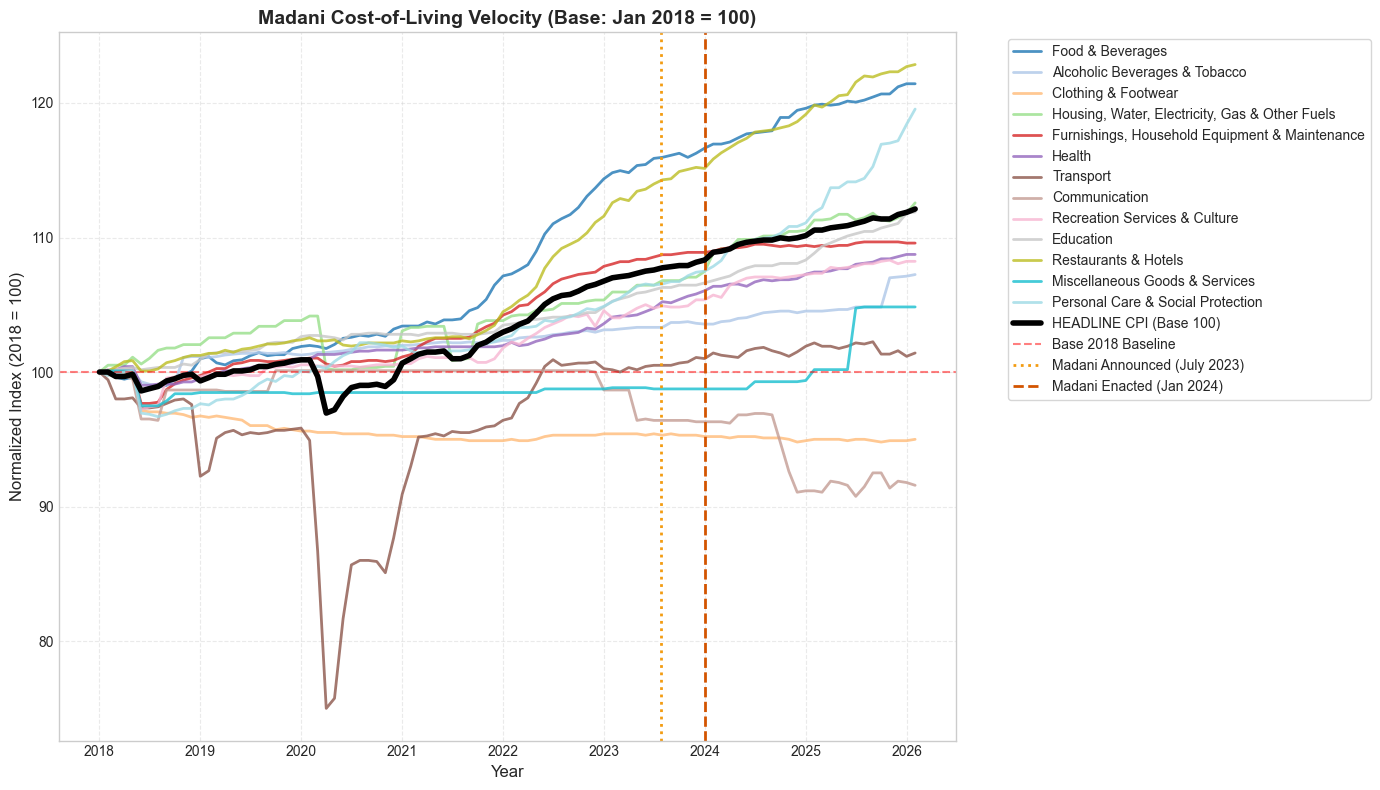

In [158]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Define the Mapping Dictionary
cpi_mapping = {
    'overall': 'All items (HEADLINE CPI)',
    '01':      'Food & Beverages',
    '02':      'Alcoholic Beverages & Tobacco',
    '03':      'Clothing & Footwear',
    '04':      'Housing, Water, Electricity, Gas & Other Fuels',
    '05':      'Furnishings, Household Equipment & Maintenance',
    '06':      'Health',
    '07':      'Transport',
    '08':      'Communication',
    '09':      'Recreation Services & Culture',
    '10':      'Education',
    '11':      'Restaurants & Hotels',
    '12':      'Miscellaneous Goods & Services',
    '13':      'Personal Care & Social Protection'
}

# 2. Filter for 2018 onwards
# Ensure the date column is in datetime format
cpi_df['date'] = pd.to_datetime(cpi_df['date'])
df_filtered = cpi_df[cpi_df['date'] >= '2018-01-01'].copy()

plt.figure(figsize=(14, 8))

# 3. Setup Unique Colors for Categories
categories = [c for c in df_filtered['division'].unique() if str(c).lower() != 'overall']
colors = plt.cm.tab20(np.linspace(0, 1, len(categories)))

# 4. Loop through and Normalize each category
for i, category in enumerate(categories):
    subset = df_filtered[df_filtered['division'] == category].sort_values('date')
    if subset.empty:
        continue
    
    # NORMALIZATION: (current / first_value_in_2018) * 100
    # This forces every line to start exactly at 100.0
    base_value = subset.iloc[0]['index']
    normalized_values = (subset['index'] / base_value) * 100
    
    label_name = cpi_mapping.get(str(category), f"Category {category}")
    plt.plot(subset['date'], normalized_values, label=label_name, color=colors[i], alpha=0.8, linewidth=2)

# 5. Highlight the 'overall' (The National Floor)
# Case-insensitive match, then normalize
overall_data = df_filtered[df_filtered['division'].str.lower() == 'overall'].sort_values('date')

if not overall_data.empty:
    base_overall = overall_data.iloc[0]['index']
    normalized_overall = (overall_data['index'] / base_overall) * 100
    
    plt.plot(overall_data['date'], normalized_overall, 
             color='black', linewidth=4, label='HEADLINE CPI (Base 100)', zorder=10)

# 6. Final Professional Formatting
plt.axhline(100, color='red', linestyle='--', alpha=0.5, label="Base 2018 Baseline")
plt.title("Madani Cost-of-Living Velocity (Base: Jan 2018 = 100)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Normalized Index (2018 = 100)", fontsize=12)
plt.axvline(announcement_date, color='#f39c12', linestyle=':', linewidth=2, label='Madani Announced (July 2023)')
    # Enactment Line
plt.axvline(enactment_date, color='#d35400', linestyle='--', linewidth=2, label='Madani Enacted (Jan 2024)')
# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='medium', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


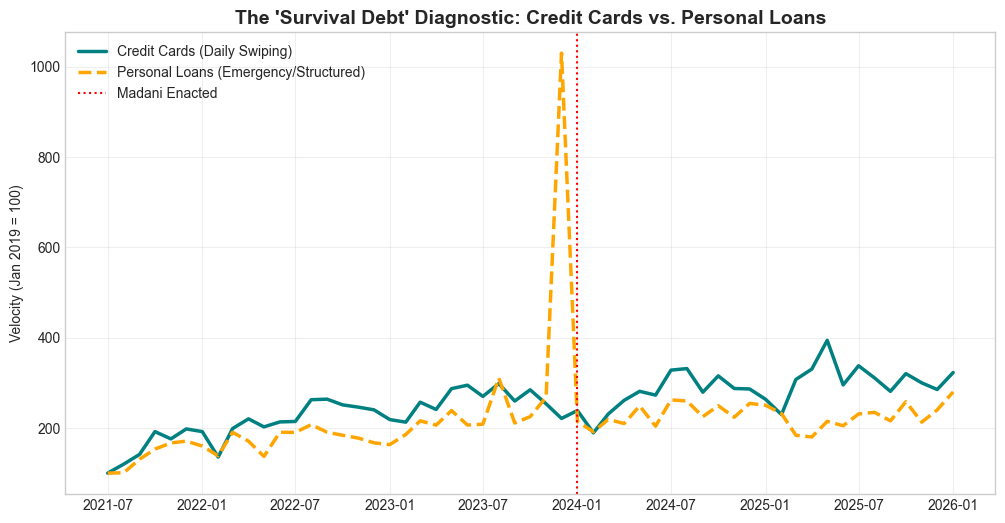

In [161]:

# Assuming df_1_12_fixed is already processed from your code
# 1. Filter for 2019 onwards
df_compare = df_1_12_fixed[df_1_12_fixed.index >= '2019-01-01'].copy()

# 2. Normalize to Jan 2019 = 100
# This allows us to compare the VELOCITY of two different scales
cc_base = df_compare['Loans_Approved_Credit_Cards'].iloc[0]
pl_base = df_compare['Loans_Approved_Personal_Use_Total'].iloc[0]

df_compare['CC_Velocity'] = (df_compare['Loans_Approved_Credit_Cards'] / cc_base) * 100
df_compare['PL_Velocity'] = (df_compare['Loans_Approved_Personal_Use_Total'] / pl_base) * 100

# 3. Plotting the "Debt Driver" Diagnostic
plt.figure(figsize=(12, 6))

plt.plot(df_compare.index, df_compare['CC_Velocity'], 
         label='Credit Cards (Daily Swiping)', color='teal', linewidth=2.5)
plt.plot(df_compare.index, df_compare['PL_Velocity'], 
         label='Personal Loans (Emergency/Structured)', color='orange', linewidth=2.5, linestyle='--')

# Highlight the Madani Era Start
plt.axvline(pd.Timestamp('2024-01-01'), color='red', linestyle=':', label='Madani Enacted')

plt.title("The 'Survival Debt' Diagnostic: Credit Cards vs. Personal Loans", fontsize=14, fontweight='bold')
plt.ylabel("Velocity (Jan 2019 = 100)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# Save the diagnostic data for your report
df_compare[['CC_Velocity', 'PL_Velocity']].to_csv('debt_velocity_check.csv')
plt.savefig('debt_driver_diagnostic.png')


In [172]:
df_1_12_fixed.columns


Index(['Year', 'Month', 'Loans_Approved_Purchase_of_Securities',
       'Loans_Approved_Passenger_Cars', 'Loans_Approved_Residential_Prop',
       'Loans_Approved_Non_Residential_Prop',
       'Loans_Approved_Personal_Use_Total', 'Loans_Approved_Credit_Cards',
       'Loans_Approved_Construction', 'Loans_Approved_Working_Capital',
       'Total_Loans_Approved_All_Purposes', 'Productivity_Ratio',
       'Food_Debt_Velocity', 'Asset_Debt_Velocity'],
      dtype='str')

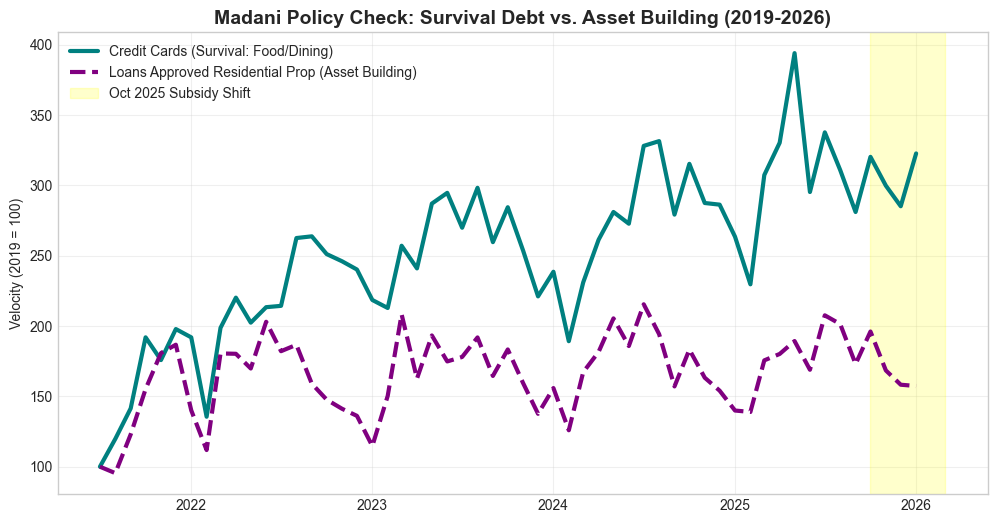

In [173]:
import matplotlib.pyplot as plt

# 1. Normalize both to Jan 2019 = 100
# If 'Loans_Approved_Consumer_Durables' is missing, use 'Loans_Approved_Passenger_Cars'
durable_col = 'Loans_Approved_Consumer_Durables' if 'Loans_Approved_Consumer_Durables' in df_1_12_fixed.columns else 'Loans_Approved_Residential_Prop'

cc_base = df_1_12_fixed['Loans_Approved_Credit_Cards'].iloc[0]
dur_base = df_1_12_fixed[durable_col].iloc[0]

df_1_12_fixed['Food_Debt_Velocity'] = (df_1_12_fixed['Loans_Approved_Credit_Cards'] / cc_base) * 100
df_1_12_fixed['Asset_Debt_Velocity'] = (df_1_12_fixed[durable_col] / dur_base) * 100

# 2. Plotting the Contrast
plt.figure(figsize=(12, 6))

plt.plot(df_1_12_fixed.index, df_1_12_fixed['Food_Debt_Velocity'], 
         label='Credit Cards (Survival: Food/Dining)', color='teal', linewidth=3)
plt.plot(df_1_12_fixed.index, df_1_12_fixed['Asset_Debt_Velocity'], 
         label=f'{durable_col.replace("_", " ")} (Asset Building)', color='purple', linewidth=3, linestyle='--')

# Target #7 Highlight (Subsidy Removal Window)
plt.axvspan('2025-10-01', '2026-03-01', color='yellow', alpha=0.2, label='Oct 2025 Subsidy Shift')

plt.title("Madani Policy Check: Survival Debt vs. Asset Building (2019-2026)", fontsize=14, fontweight='bold')
plt.ylabel("Velocity (2019 = 100)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()
